# Hyperalgesia
**Description:** EDA, Statistical and Machine Learning Models to Understand<br>
**Author:** [Pooja Singhal]()<br>
**Date created:** 2026/02/02<br>
**Last modified:** 2026/02/24<br>


In [1]:
import os
import tqdm

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import LinearSVR

from sklearn.preprocessing import StandardScaler
from sklearn import metrics as sk_metrics

import skopt

from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict, KFold

%config InlineBackend.figure_format='retina'

In [ ]:
class SafeTqdmCallback:
    """
    A custom callback class that prevents Jupyter's HMAC output stream 
    from being pickled by joblib's multiprocessing workers.
    """
    def __init__(self, n_iter, desc="Optimizing", ncols=100):
        self.n_iter = n_iter
        self.pbar = tqdm.tqdm(total=n_iter, desc=desc, ncols=ncols)

    def __call__(self, optim_result):
        self.pbar.update(1)
        # Automatically close the progress bar when done
        if self.pbar.n >= self.n_iter:
            self.pbar.close()
        return False  # Return True to stop early

    def __getstate__(self):
        # MAGIC TRICK: When joblib tries to pickle this object to send to workers,
        # we give it a copy of the state with the 'pbar' removed.
        # This completely bypasses the HMAC PicklingError.
        state = self.__dict__.copy()
        state['pbar'] = None 
        return state

    def __setstate__(self, state):
        self.__dict__.update(state)

In [2]:
random_state = None

tab10_colors = list(mpl.colors.TABLEAU_COLORS.keys())
print(tab10_colors)

['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']


In [3]:
data_dir = os.path.join("..","data","proc")
data_dir

'../data/proc'

In [4]:
df_b04 = pd.read_csv(os.path.join(data_dir,"behavior_04week.csv"))
df_b12 = pd.read_csv(os.path.join(data_dir,"behavior_12week.csv"))
df_g04 = pd.read_csv(os.path.join(data_dir, "genetic_04week.csv"))
df_g12 = pd.read_csv(os.path.join(data_dir, "genetic_12week.csv"))

In [5]:
df_b04.head(3)

,group_id,body_wt,brain_wt,cgrt_cnt,nctn_mg,dose_mg,hypalg_bfr,hypalg_aft
0,1,412.0,1.1,0,0,0.0,5,0
1,1,399.4,1.2,0,0,0.0,4,0
2,1,456.8,1.1,0,0,0.0,3,0


In [6]:
df_g04.head(3)

,group_id,cgrt_cnt,nctn_mg,dose_mg,nAChR,BDNF_n,Trk-β,BDNF_T,BDNF_I,IL-6,iNOS,Nrf-2
0,1,0,0,0,8,4,5,7,5,1,1,5
1,1,0,0,0,7,6,6,5,8,2,0,7
2,1,0,0,0,6,5,3,4,7,2,0,4


# Pre-processing

In [7]:
# Setting AFTER value to BEFORE value where reported 0 (Control Groups)
df_b04.loc[df_b04["hypalg_aft"]==0, "hypalg_aft"] = df_b04[df_b04["hypalg_aft"]==0]["hypalg_bfr"]
df_b12.loc[df_b12["hypalg_aft"]==0, "hypalg_aft"] = df_b12[df_b12["hypalg_aft"]==0]["hypalg_bfr"]

## Q1. The "Multiple BDNF" Columns
- Checking if multiple BDNF columns can be averaged
  - Under stronger correlation, if not implies regional heterogeneity or staining variability

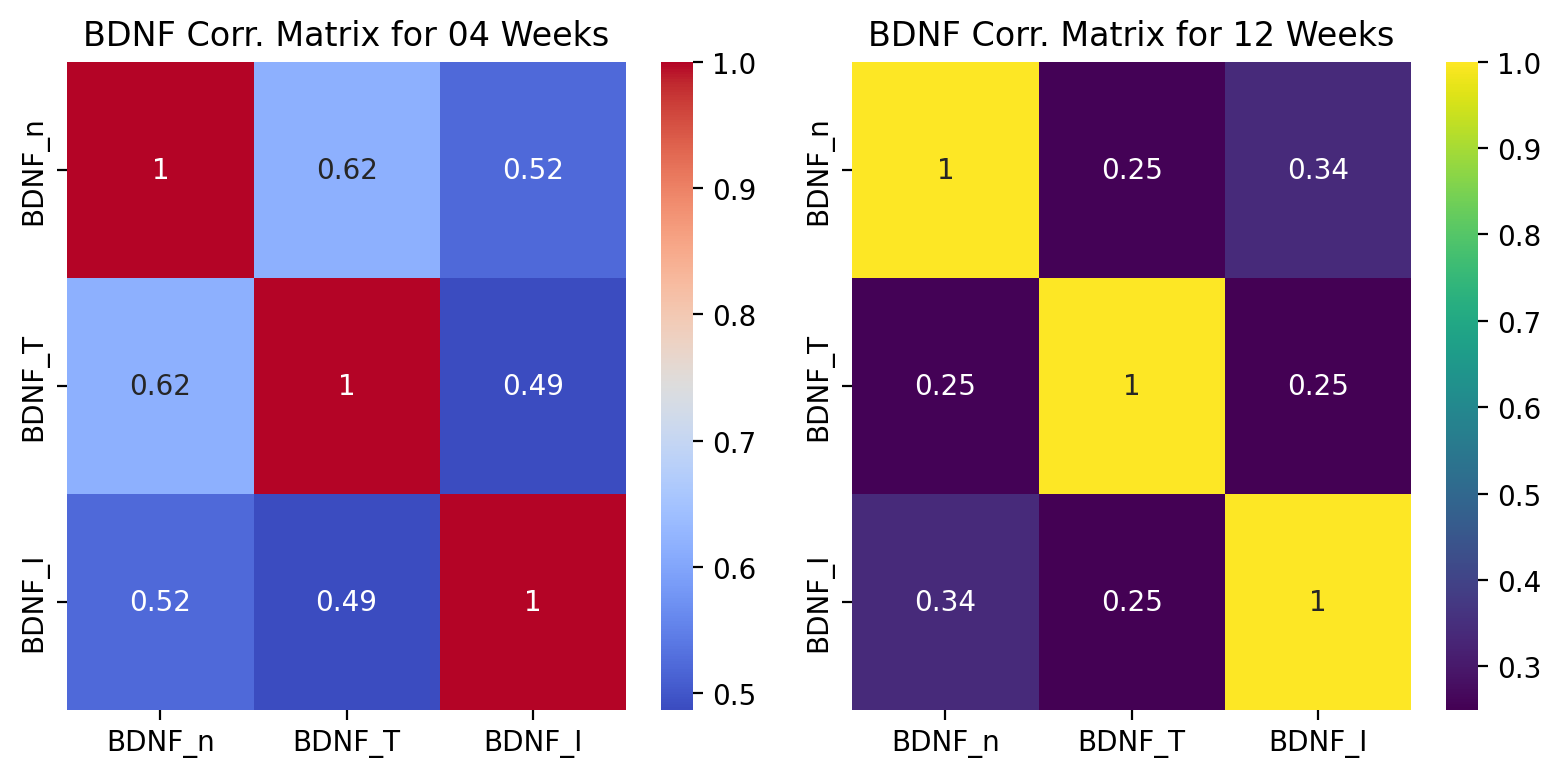

In [8]:
# Compute correlation matrices for 3 BDNF columns, in 4 and 12 week studies
cols_BDNF = [col for col in df_g04.columns if 'BDNF' in col]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
sns.heatmap(df_g04[cols_BDNF].corr(), annot=True, cmap='coolwarm', ax=axes[0])
sns.heatmap(df_g12[cols_BDNF].corr(), annot=True, cmap='viridis' , ax=axes[1])

axes[0].set_title('BDNF Corr. Matrix for 04 Weeks')
axes[1].set_title('BDNF Corr. Matrix for 12 Weeks')

plt.tight_layout() # Adjust layout to prevent titles and labels from overlapping

## Q2. The "N" Mismatch (Behavior n=5 vs. Genetic n=10)
- Mismatch between Behavior (10 Groups, 5 Rodents) and Genetic (5 Sub-Groups, 10 Rodents)
  - Spread of values within each group comparable to mean value limits the applicability of taking direct mean value (but it is only option due to mismatch)

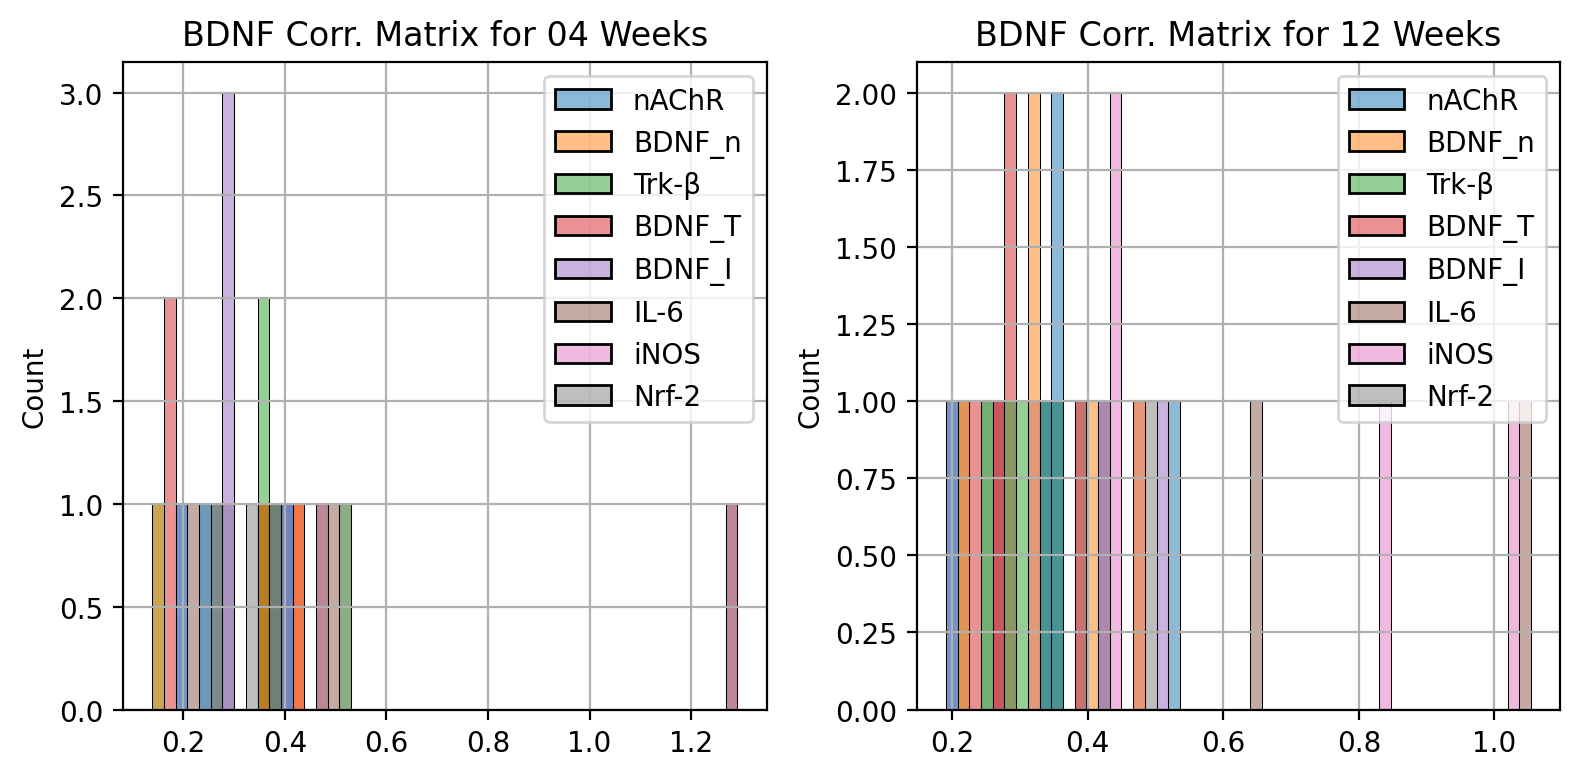

In [9]:
# Compute StandardDeviation/Mean for each GENE expression within each group
cols_GENE = ['nAChR', 'BDNF_n', 'Trk-β', 'BDNF_T', 'BDNF_I', 'IL-6', 'iNOS', 'Nrf-2']

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
sns.histplot(( df_g04.groupby(by='group_id').std() / df_g04.groupby(by='group_id').mean() )[cols_GENE], bins=50, ax=axes[0])
sns.histplot(( df_g12.groupby(by='group_id').std() / df_g12.groupby(by='group_id').mean() )[cols_GENE], bins=50, ax=axes[1])

axes[0].set_title('BDNF Corr. Matrix for 04 Weeks'), axes[0].grid(True)
axes[1].set_title('BDNF Corr. Matrix for 12 Weeks'), axes[1].grid(True)

plt.tight_layout() # Adjust layout to prevent titles and labels from overlapping

## Q3. Imputing for the Missing Groups in Genetics Data
- Genetic data only has 5 groups, so either exclude 5 groups from behavior data as well, or do Imputation (which can be limited)
  - Model parameters does not vary much across K-fold CV, specially for 4-week Study
  - Linear Imputation is done to predict average GENE expression for remaining 5 groups

In [ ]:
def get_averaged_imputed_gene_expression_all_groups(df_b, df_g, use_imputation=True, n_folds=10, n_iter=32, verbose=True, ax=None):
    # Number of groups in behavioral vs genetic data
    if verbose:
        print(f'Groups in Behavioral vs Genetic Data are {df_b['group_id'].nunique()}, {df_g['group_id'].nunique()}')
    
    # 0. Selecting Study group columns and Gene expression columns to learn ElasticNet based Imputation
    cols_STUDY, cols_GENE,  = ['cgrt_cnt', 'nctn_mg', 'dose_mg'], ['nAChR', 'BDNF_n', 'Trk-β', 'BDNF_T', 'BDNF_I', 'IL-6', 'iNOS', 'Nrf-2']
    X, y_true = df_g[cols_STUDY], df_g[cols_GENE]

    # 1. Initialize the Elastic Net model
    model = ElasticNet(random_state=random_state)

    # 2. Define the search space for Bayesian Optimization
    search_space = {
        'alpha'    : skopt.space.Real(1e-3, 1e+1  , prior='log-uniform'), # alpha: Regularization strength
        'l1_ratio' : skopt.space.Real(1e-3, 1-1e-3, prior='uniform')      # l1_ratio: 1.0 is Lasso, 0.0 is Ridge
    }

    # 3. Setup the Bayesian Search with 10-fold CV
    opt = skopt.BayesSearchCV(
        estimator=model, search_spaces=search_space, n_iter=n_iter, # n_iter determines how many parameter combinations to try
        cv=KFold(n_splits=n_folds, shuffle=True, random_state=random_state), n_jobs=-1, scoring='neg_mean_squared_error'
    )

    # 4. Fit the optimizer to find the best hyperparameters
    if not verbose:
        opt.fit(X, y_true)
    else:
        # Initialize our safe callback
        on_step = SafeTqdmCallback(n_iter=opt.n_iter, desc="Optimizing Elastic Net", ncols=150)
        # pbar = tqdm.tqdm(total=opt.n_iter, desc="Optimizing Elastic Net", ncols=150)
        # def on_step(optim_result):
        #     pbar.update(1)
        #     return False  # Return True to stop the search early if needed
        # Run the fit with n_jobs=-1 safely
        opt.fit(X, y_true, callback=on_step)
        # pbar.close()

    # 5. Generate cross-validated predictions using the best model, and calculate absolute errors
    y_pred = cross_val_predict(
        opt.best_estimator_, # This uses the best_estimator_ found during the search
        X, y_true, cv=KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    )
    y_pred = pd.DataFrame(y_pred, columns=y_true.columns)
    if verbose:
        print(f"Best Parameters: {opt.best_params_}", f"MAE is {sk_metrics.mean_absolute_error(y_true, y_pred)}")

    # NOT RELEVANT : MAE or MSE error would be close to scale of Standard-Deviation only
    # y_abs_err = np.abs(y_true - y_pred)
    # y_true['group_id'] = y_pred['group_id'] = y_abs_err['group_id'] = df_g12['group_id']
    # y_abs_err.groupby(by='group_id').mean() / y_true.groupby(by='group_id').std()

    # 6. Use best model, and obtain 10 models, one for each of K-fold, to assess inter-fold variation in model parameters
    cv_results = cross_validate(opt.best_estimator_, X, y_true, cv=KFold(n_splits=10, shuffle=True, random_state=random_state), return_estimator=True)

    # 7. Extract intercepts and coefficients from each of the K-Fold's models
    fold_coefs      = np.array([model.coef_      for model in cv_results['estimator']])
    fold_intercepts = np.array([model.intercept_ for model in cv_results['estimator']])

    # 8. Plot Coefficient of Variations (CoVs) for model parameters across K-Folds
    if verbose:
        cov_coefs      = np.ravel(fold_coefs.std(axis=0)/np.abs(fold_coefs).mean(axis=0))
        cov_intercepts = fold_intercepts.std(axis=0)/np.abs(fold_intercepts).mean(axis=0)
        sns.histplot( cov_coefs     , kde=True, stat='probability', ax=ax, label=f'$Coefficients\\: \mu={cov_coefs.mean():.3g}$' )
        sns.histplot( cov_intercepts, kde=True, stat='probability', ax=ax, label=f'$Intercepts\\: \mu={cov_intercepts.mean():.3g}$' )
        ax.legend(), ax.grid(True)

    # 9. The final model trained on all data (X, y_true)
    final_coefs = opt.best_estimator_.coef_
    final_intercept = opt.best_estimator_.intercept_
    final_intercept.shape, final_coefs.shape

    # 10. Obtains groups in Behavioral data, for which we do not have gene expression dataset
    groups_imputable = [int(group_id) for group_id in df_b['group_id'].unique() if group_id not in df_g['group_id'].unique()]

    # 11. Obtained the values of study parameters (Cigratte, Oral Nicotine and Mecalymine Dosage)
    X_imp = df_b.groupby(by='group_id').mean().loc[groups_imputable,cols_STUDY].to_numpy()

    # 12. Obtain using linear regression the mean values for absent groupd
    y_imp = X_imp @ final_coefs.T + final_intercept
    y_imp = pd.DataFrame(y_imp, columns=cols_GENE)

    # 13. Prepare both of the datasets
    df_1 = df_g.groupby(by='group_id').mean().reset_index()
    if use_imputation:
        df_2 = pd.concat((df_b.groupby(by='group_id').mean().loc[groups_imputable,cols_STUDY].reset_index(), y_imp), axis='columns')
    else:
        df_2 = pd.DataFrame()

    # 14. Merge both datasets into a common dataset, to be used along with diverse Behavioral data
    df_g_agg = pd.concat((df_1, df_2), axis='index')
    df_g_agg.sort_values(by=['group_id'], inplace=True)
    return df_g_agg

<>:61: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:62: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:61: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:62: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/mp/8yktm0993ps3_9m6bzp4yqcc0000gn/T/ipykernel_84611/3988893273.py:61: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  sns.histplot( cov_coefs     , kde=True, stat='probability', ax=ax, label=f'$Coefficients\\: \mu={cov_coefs.mean():.3g}$' )
/var/folders/mp/8yktm0993ps3_

Groups in Behavioral vs Genetic Data are 10, 5


Optimizing Elastic Net:  60%|█████████████████████████████████████████████████████▍                                   | 12/20 [00:00<00:00, 19.78it/s]/Users/chaudhary/miniforge3/envs/py314/lib/python3.14/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [0.001, 0.001] before, using random point [0.001155118534739246, 0.8719759340343475]
  warnings.warn(
Optimizing Elastic Net:  80%|███████████████████████████████████████████████████████████████████████▏                 | 16/20 [00:01<00:00, 10.76it/s]/Users/chaudhary/miniforge3/envs/py314/lib/python3.14/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [0.001, 0.001] before, using random point [0.4420404926458036, 0.6543710197837773]
  warnings.warn(
/Users/chaudhary/miniforge3/envs/py314/lib/python3.14/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [0.001, 0.001] before, usin

Best Parameters: OrderedDict({'alpha': 0.001, 'l1_ratio': 0.001}) MAE is 1.5101893960180672
Groups in Behavioral vs Genetic Data are 10, 5


Optimizing Elastic Net: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:02<00:00,  9.59it/s]

Best Parameters: OrderedDict({'alpha': 0.008110241544610163, 'l1_ratio': 0.726385301313817}) MAE is 1.6508567928141273


,group_id,cgrt_cnt,nctn_mg,dose_mg,nAChR,BDNF_n,Trk-β,BDNF_T,BDNF_I,IL-6,iNOS,Nrf-2
0,1,0.0,0.0,0.0,5.000000,4.800000,4.900000,4.100000,6.000000,1.200000,0.400000,5.600000
1,2,2.0,0.0,0.0,7.500000,8.700000,7.900000,8.600000,7.000000,3.900000,4.800000,3.000000
0,3,2.0,0.0,1.5,6.148683,7.147763,6.648425,6.747818,5.049672,3.348028,3.047958,4.551473
2,4,2.0,0.0,3.0,4.800000,5.600000,5.400000,4.900000,3.100000,2.800000,1.300000,6.100000
1,5,0.0,6.0,0.0,7.428026,7.396912,7.231276,7.050094,7.330747,4.740711,3.468873,4.234517


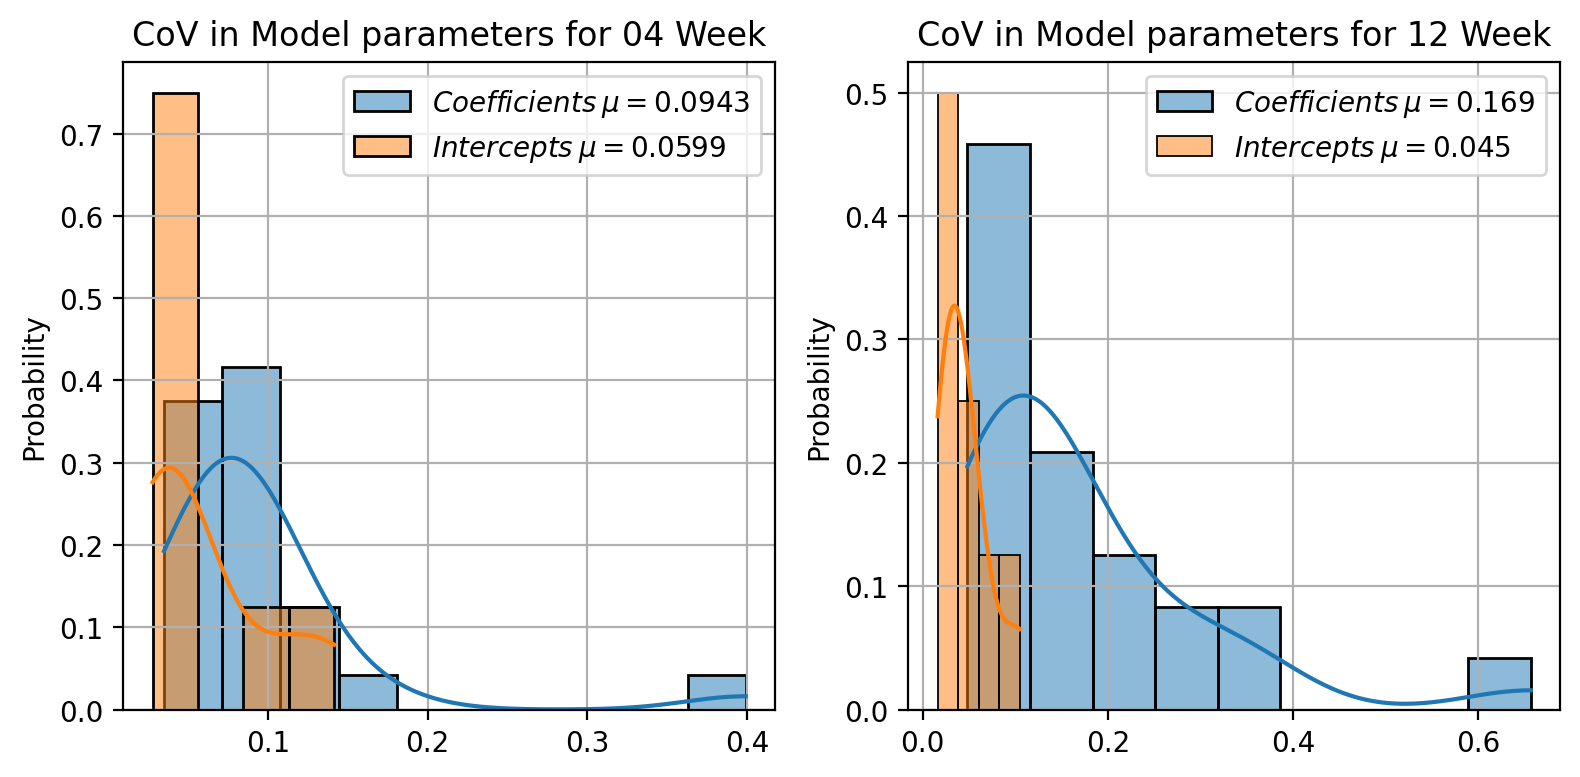

In [53]:
# Picking both of 04 or 12 week study for GENETIC data Imputation
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

df_g04_agg = get_averaged_imputed_gene_expression_all_groups(df_b04, df_g04, use_imputation=True, n_iter=20, verbose=True, ax=axes[0])
df_g12_agg = get_averaged_imputed_gene_expression_all_groups(df_b12, df_g12, use_imputation=True, n_iter=20, verbose=True, ax=axes[1])

axes[0].set_title('CoV in Model parameters for 04 Week'), axes[0].grid(True)
axes[1].set_title('CoV in Model parameters for 12 Week'), axes[1].grid(True)

plt.tight_layout() # Adjust layout to prevent titles and labels from overlapping

df_g04_agg.head()

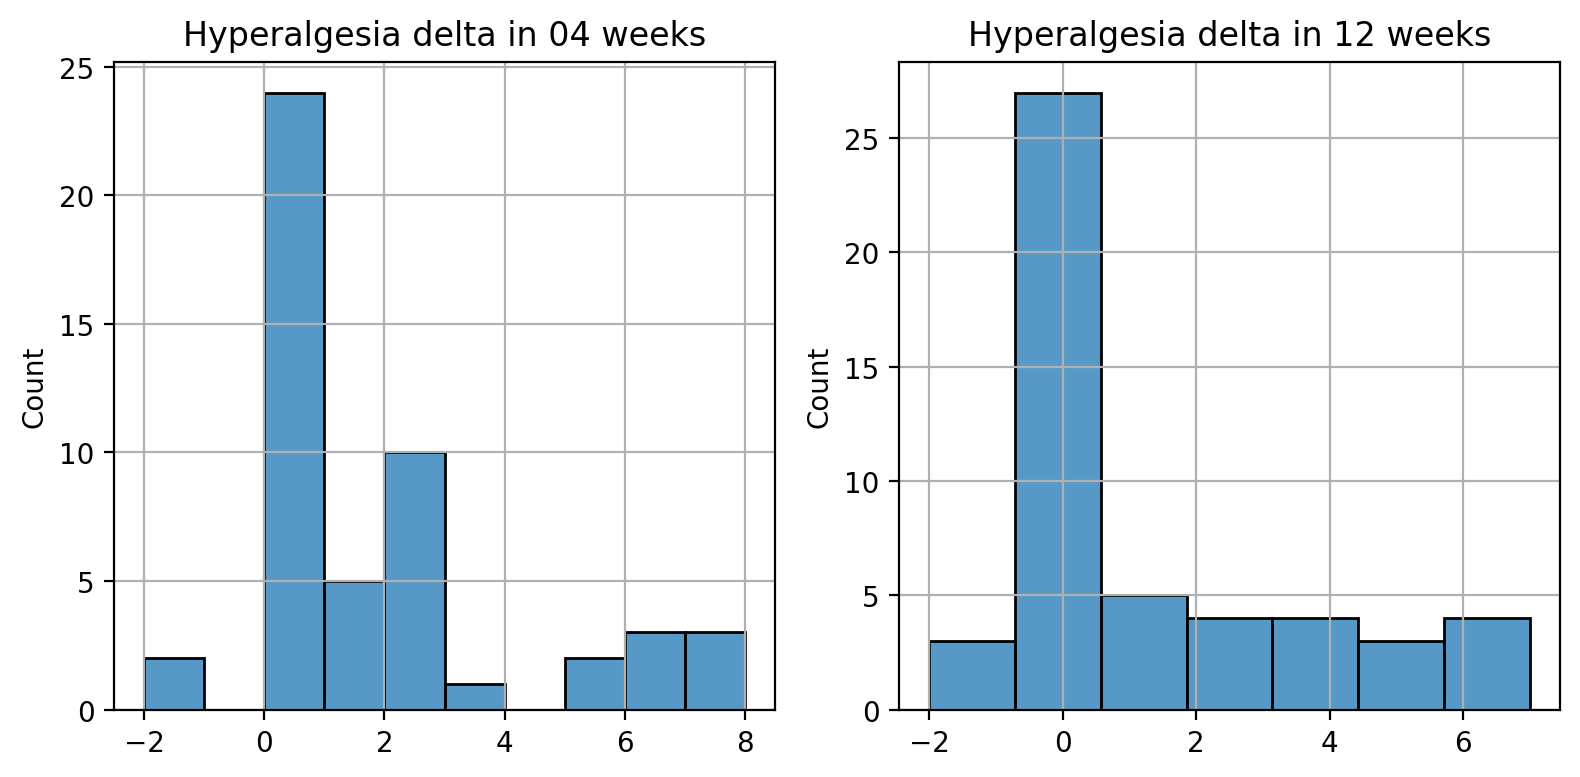

In [54]:
# Compute StandardDeviation/Mean for each GENE expression within each group
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
sns.histplot(df_b04['hypalg_aft']-df_b04['hypalg_bfr'], ax=axes[0])
sns.histplot(df_b12['hypalg_aft']-df_b12['hypalg_bfr'], ax=axes[1])

axes[0].set_title('Hyperalgesia delta in 04 weeks'), axes[0].grid(True)
axes[1].set_title('Hyperalgesia delta in 12 weeks'), axes[1].grid(True)

plt.tight_layout() # Adjust layout to prevent titles and labels from overlapping

In [55]:
# Computing absolute and relative delta in Latency
df_b04['hypalg_del'] = np.maximum(0,df_b04['hypalg_aft'] - df_b04['hypalg_bfr'])
df_b12['hypalg_del'] = np.maximum(0,df_b12['hypalg_aft'] - df_b12['hypalg_bfr'])

df_b04['hypalg_rel'] = df_b04['hypalg_del'] / df_b04['hypalg_bfr']
df_b12['hypalg_rel'] = df_b12['hypalg_del'] / df_b12['hypalg_bfr']


# Creating combined datasets
# CHECKPOINT: Currently only mean values of Gene Expression is used, Standard-Deviation can be added as well
# Additional additional 8 columns, on just 50 rows can be challenging, needs suitable feature selection method
df_04 = pd.merge(left=df_b04, right=df_g04_agg, on=['group_id', 'cgrt_cnt', 'nctn_mg', 'dose_mg'], how='inner')
df_12 = pd.merge(left=df_b12, right=df_g12_agg, on=['group_id', 'cgrt_cnt', 'nctn_mg', 'dose_mg'], how='inner')

In [56]:
df_04.head()

,group_id,body_wt,brain_wt,cgrt_cnt,nctn_mg,dose_mg,hypalg_bfr,hypalg_aft,hypalg_del,hypalg_rel,nAChR,BDNF_n,Trk-β,BDNF_T,BDNF_I,IL-6,iNOS,Nrf-2
0,1,412.0,1.1,0,0,0.0,5,5,0,0.0,5.0,4.8,4.9,4.1,6.0,1.2,0.4,5.6
1,1,399.4,1.2,0,0,0.0,4,4,0,0.0,5.0,4.8,4.9,4.1,6.0,1.2,0.4,5.6
2,1,456.8,1.1,0,0,0.0,3,3,0,0.0,5.0,4.8,4.9,4.1,6.0,1.2,0.4,5.6
3,1,370.4,1.4,0,0,0.0,4,4,0,0.0,5.0,4.8,4.9,4.1,6.0,1.2,0.4,5.6
4,1,356.4,1.3,0,0,0.0,8,8,0,0.0,5.0,4.8,4.9,4.1,6.0,1.2,0.4,5.6


In [57]:
df_04['study_duration'] = 4
df_12['study_duration'] = 12

df = pd.concat((df_04,df_12), axis='index')

In [58]:
df.group_id.nunique()

10

# Statistical Methods (The "Mechanism" Validators)

## Linear Mixed-Effects Models (LMM)

In [33]:
import statsmodels.formula.api as smf

# 1. Ensure Categorical Variables are handled correctly
# We use C() in the formula to tell statsmodels these are factors
df['group_id'] = df['group_id'].astype('category')
df['study_duration'] = df['study_duration'].astype('category')

# 2. Define the Model
# Formula logic: 
# hypalg_aft (Outcome) is predicted by:
# baseline (hypalg_bfr) + drug dose (dose_mg) + time (study_duration) + Genetic Marker (BDNF_n)
# We use an interaction (*) between dose and duration to see if the drug 
# works differently over time.
formula = "hypalg_aft ~ hypalg_bfr + dose_mg * C(study_duration) + BDNF_n"

# 3. Fit the Model
# groups='group_id' defines the Random Intercept.
# This accounts for the nesting of 5 rats per group.
lmm_model = smf.mixedlm(formula, df, groups=df["group_id"])
lmm_results = lmm_model.fit()

# 4. Output the Results
print("--- Linear Mixed-Effects Model (LMM) Results ---")
print(lmm_results.summary())

# 5. Extraction for your Report
# p-values for your 'Mechanism'
p_values = lmm_results.pvalues
print("\nSignificance of BDNF_n as a predictor:", p_values['BDNF_n'])

--- Linear Mixed-Effects Model (LMM) Results ---
                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       hypalg_aft
No. Observations:       100           Method:                   REML      
No. Groups:             10            Scale:                    3.0722    
Min. group size:        10            Log-Likelihood:           -203.3949 
Max. group size:        10            Converged:                Yes       
Mean group size:        10.0                                              
--------------------------------------------------------------------------
                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                        5.852    2.423  2.415 0.016  1.103 10.601
C(study_duration)[T.12]         -0.263    0.674 -0.390 0.697 -1.584  1.058
hypalg_bfr                       0.123    0.158  0.777 0.437 -0.187  0

In [34]:
df.columns

Index(['group_id', 'body_wt', 'brain_wt', 'cgrt_cnt', 'nctn_mg', 'dose_mg',
       'hypalg_bfr', 'hypalg_aft', 'hypalg_del', 'hypalg_rel', 'nAChR',
       'BDNF_n', 'Trk-β', 'BDNF_T', 'BDNF_I', 'IL-6', 'iNOS', 'Nrf-2',
       'study_duration'],
      dtype='str')

## Canonical Correlation Analysis (CCA)

In [59]:
from sklearn.cross_decomposition import CCA

# 1. Define the Feature Sets
# Set X: The multiple ways we measured BDNF (and its receptor/cytokine if desired)
# We focus on the three BDNF columns to create the specific "BDNF_SUP"
genetic_cols = ['BDNF_n', 'BDNF_T', 'BDNF_I', 'Trk-β', 'IL-6']

# Set Y: The behavioral outcomes we want to explain
behavioral_cols = ['hypalg_aft', 'hypalg_rel']

# 2. Pre-processing: Standardization is MANDATORY for CCA
# CCA is sensitive to scale; we must Z-score the data first.
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X = scaler_x.fit_transform(df[genetic_cols])
Y = scaler_y.fit_transform(df[behavioral_cols])

# 3. Initialize and Fit CCA
# We extract 1 component (the "Super Signal")
cca = CCA(n_components=1)
cca.fit(X, Y)

# 4. Transform the Genetic Data into the Latent Space
# This creates the new "Super BDNF" coordinates
x_c, y_c = cca.transform(X, Y)

# 5. Add to Dataframe
# x_c is a 2D array, we take the first column and add it as BDNF_SUP
df['BDNF_SUP'] = x_c[:, 0]

# 6. Validation: Check the "Loadings"
# Loadings tell you how much each original column contributed to BDNF_SUP
loadings = pd.DataFrame(cca.x_loadings_, index=genetic_cols, columns=['Contribution'])
print("--- Genetic Loadings for BDNF_SUP ---")
print(loadings.sort_values(by='Contribution', ascending=False))

# 7. Correlation Check
# We want to ensure BDNF_SUP is positively correlated with our raw BDNF
corr = df['BDNF_SUP'].corr(df['BDNF_n'])
if corr < 0:
    # CCA components are sign-invariant; if it's flipped, we flip it back
    # so that "High BDNF_SUP" means "High BDNF"
    df['BDNF_SUP'] = -df['BDNF_SUP']
    print("\nNote: Component sign flipped to align with raw BDNF direction.")

print(f"\nCorrelation between BDNF_SUP and raw BDNF_n: {df['BDNF_SUP'].corr(df['BDNF_n']):.4f}")
print("New column 'BDNF_SUP' successfully added to dataframe.")

--- Genetic Loadings for BDNF_SUP ---
        Contribution
BDNF_T      0.930007
BDNF_I      0.901104
Trk-β       0.894487
BDNF_n      0.877284
IL-6        0.668855

Correlation between BDNF_SUP and raw BDNF_n: 0.8506
New column 'BDNF_SUP' successfully added to dataframe.


In [37]:
# LMM Again, but on BDNF_SUP columns

# 1. Ensure Categorical Variables are handled correctly
# We use C() in the formula to tell statsmodels these are factors
df['group_id'] = df['group_id'].astype('category')
df['study_duration'] = df['study_duration'].astype('category')

# 2. Define the Model
# Formula logic: 
# hypalg_aft (Outcome) is predicted by:
# baseline (hypalg_bfr) + drug dose (dose_mg) + time (study_duration) + Genetic Marker (BDNF_SUP)
# We use an interaction (*) between dose and duration to see if the drug 
# works differently over time.
formula = "hypalg_aft ~ hypalg_bfr + dose_mg * C(study_duration) + BDNF_SUP"

# 3. Fit the Model
# groups='group_id' defines the Random Intercept.
# This accounts for the nesting of 5 rats per group.
lmm_model = smf.mixedlm(formula, df, groups=df["group_id"])
lmm_results = lmm_model.fit()

# 4. Output the Results
print("--- Linear Mixed-Effects Model (LMM) Results ---")
print(lmm_results.summary())

# 5. Extraction for your Report
# p-values for your 'Mechanism'
p_values = lmm_results.pvalues
print("\nSignificance of BDNF_n as a predictor:", p_values['BDNF_SUP'])

--- Linear Mixed-Effects Model (LMM) Results ---
                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       hypalg_aft
No. Observations:       100           Method:                   REML      
No. Groups:             10            Scale:                    3.0602    
Min. group size:        10            Log-Likelihood:           -202.2488 
Max. group size:        10            Converged:                Yes       
Mean group size:        10.0                                              
--------------------------------------------------------------------------
                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                        3.208    0.782  4.104 0.000  1.676  4.740
C(study_duration)[T.12]         -0.228    0.592 -0.386 0.700 -1.388  0.932
hypalg_bfr                       0.115    0.154  0.748 0.454 -0.187  0

## Mediation Analysis (Process Macro / SEM)

In [38]:
import statsmodels.api as sm

def perform_mediation(df, x_col, m_col, y_col, n_boots=1000):
    # 1. Path A: Dose -> BDNF_SUP
    model_a = sm.OLS(df[m_col], sm.add_constant(df[x_col])).fit()
    coeff_a = model_a.params[x_col]
    
    # 2. Path B & C': BDNF_SUP + Dose -> Pain (hypalg_aft)
    X_bc = sm.add_constant(df[[x_col, m_col]])
    model_bc = sm.OLS(df[y_col], X_bc).fit()
    coeff_b = model_bc.params[m_col]
    coeff_c_prime = model_bc.params[x_col]
    
    # 3. Indirect Effect (a * b)
    indirect_effect = coeff_a * coeff_b
    
    # 4. Bootstrapping for Confidence Intervals
    boot_indirect_effects = []
    for _ in range(n_boots):
        sample = df.sample(frac=1, replace=True)
        # Re-run Path A
        a_boot = sm.OLS(sample[m_col], sm.add_constant(sample[x_col])).fit().params[x_col]
        # Re-run Path B
        b_boot = sm.OLS(sample[y_col], sm.add_constant(sample[[x_col, m_col]])).fit().params[m_col]
        boot_indirect_effects.append(a_boot * b_boot)
    
    ci_lower = np.percentile(boot_indirect_effects, 2.5)
    ci_upper = np.percentile(boot_indirect_effects, 97.5)
    
    print(f"--- Mediation Analysis: {x_col} -> {m_col} -> {y_col} ---")
    print(f"Direct Effect (c'): {coeff_c_prime:.4f}")
    print(f"Indirect Effect (ab): {indirect_effect:.4f}")
    print(f"95% Bootstrap CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
    
    if ci_lower * ci_upper > 0:
        print("\nRESULT: Significant Mediation Found (CI does not cross zero).")
    else:
        print("\nRESULT: Mediation is not statistically significant.")

# Run the analysis
perform_mediation(df, x_col='dose_mg', m_col='BDNF_SUP', y_col='hypalg_aft')

--- Mediation Analysis: dose_mg -> BDNF_SUP -> hypalg_aft ---
Direct Effect (c'): 0.3115
Indirect Effect (ab): 0.3687
95% Bootstrap CI: [0.2067, 0.5599]

RESULT: Significant Mediation Found (CI does not cross zero).


In [40]:
perform_mediation(df, x_col='dose_mg', m_col='BDNF_SUP', y_col='hypalg_del')

--- Mediation Analysis: dose_mg -> BDNF_SUP -> hypalg_del ---
Direct Effect (c'): 0.7959
Indirect Effect (ab): 0.0650
95% Bootstrap CI: [-0.0711, 0.2147]

RESULT: Mediation is not statistically significant.


In [41]:
perform_mediation(df, x_col='dose_mg', m_col='BDNF_SUP', y_col='hypalg_rel')

--- Mediation Analysis: dose_mg -> BDNF_SUP -> hypalg_rel ---
Direct Effect (c'): 0.6189
Indirect Effect (ab): 0.0283
95% Bootstrap CI: [-0.1017, 0.1693]

RESULT: Mediation is not statistically significant.


In [60]:
import statsmodels.api as sm

def perform_robust_mediation(df, x_col, m_col, y_col, cov_cols, n_boots=1000):
    """
    Performs mediation while controlling for baseline (hypalg_bfr) 
    and other covariates (study_duration).
    """
    # 1. Path A: Dose -> BDNF_SUP (Control for baseline and duration)
    # This checks if the drug actually changes the gene, regardless of starting point.
    X_a = sm.add_constant(df[[x_col] + cov_cols])
    model_a = sm.OLS(df[m_col], X_a).fit()
    coeff_a = model_a.params[x_col]
    
    # 2. Path B & C': Dose + BDNF_SUP -> Pain (Control for baseline and duration)
    # This checks if the gene predicts the final pain state, holding baseline constant.
    X_bc = sm.add_constant(df[[x_col, m_col] + cov_cols])
    model_bc = sm.OLS(df[y_col], X_bc).fit()
    coeff_b = model_bc.params[m_col]
    coeff_c_prime = model_bc.params[x_col]
    
    # 3. Indirect Effect (a * b)
    indirect_effect = coeff_a * coeff_b
    
    # 4. Bootstrap for Confidence Intervals
    boot_indirect_effects = []
    for i in range(n_boots):
        sample = df.sample(frac=1, replace=True)
        try:
            # Re-run Path A on bootstrap sample
            X_a_b = sm.add_constant(sample[[x_col] + cov_cols])
            a_b = sm.OLS(sample[m_col], X_a_b).fit().params[x_col]
            
            # Re-run Path B on bootstrap sample
            X_bc_b = sm.add_constant(sample[[x_col, m_col] + cov_cols])
            b_b = sm.OLS(sample[y_col], X_bc_b).fit().params[m_col]
            
            boot_indirect_effects.append(a_b * b_b)
        except:
            continue # Skip singular matrices in bootstrap
    
    ci_lower = np.percentile(boot_indirect_effects, 2.5)
    ci_upper = np.percentile(boot_indirect_effects, 97.5)
    
    print(f"--- ROBUST MEDIATION: {x_col} -> {m_col} -> {y_col} ---")
    print(f"Controlling for: {cov_cols}")
    print(f"Direct Effect (c'): {coeff_c_prime:.4f}")
    print(f"Indirect Effect (ab): {indirect_effect:.4f}")
    print(f"95% Bootstrap CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
    
    if ci_lower * ci_upper > 0:
        print("\nRESULT: SIGNIFICANT MECHANISM FOUND (Path is independent of baseline).")
    else:
        print("\nRESULT: Not significant after controlling for baseline.")

In [61]:
# RUNNING THE NEW ANALYSIS (with FUll data)
# We control for 'hypalg_bfr' (The starting point) 
# and 'study_duration' (The 4 vs 12 week difference)
perform_robust_mediation(df, 
                         x_col='dose_mg', 
                         m_col='BDNF_SUP', 
                         y_col='hypalg_aft', 
                         cov_cols=['hypalg_bfr', 'study_duration'])

--- ROBUST MEDIATION: dose_mg -> BDNF_SUP -> hypalg_aft ---
Controlling for: ['hypalg_bfr', 'study_duration']
Direct Effect (c'): 0.3759
Indirect Effect (ab): 0.3460
95% Bootstrap CI: [0.1504, 0.5986]

RESULT: SIGNIFICANT MECHANISM FOUND (Path is independent of baseline).


In [52]:
# RUNNING THE NEW ANALYSIS (with Halved data)
# Note: Run CCA before this
# We control for 'hypalg_bfr' (The starting point) 
# and 'study_duration' (The 4 vs 12 week difference)
perform_robust_mediation(df, 
                         x_col='dose_mg', 
                         m_col='BDNF_SUP', 
                         y_col='hypalg_aft', 
                         cov_cols=['hypalg_bfr', 'study_duration'])

--- ROBUST MEDIATION: dose_mg -> BDNF_SUP -> hypalg_aft ---
Controlling for: ['hypalg_bfr', 'study_duration']
Direct Effect (c'): 0.1703
Indirect Effect (ab): 0.4737
95% Bootstrap CI: [0.1570, 0.8642]

RESULT: SIGNIFICANT MECHANISM FOUND (Path is independent of baseline).


# Machine Learning (Predictive & Diagnostic)

## PLS-DA (Partial Least Squares Discriminant Analysis)

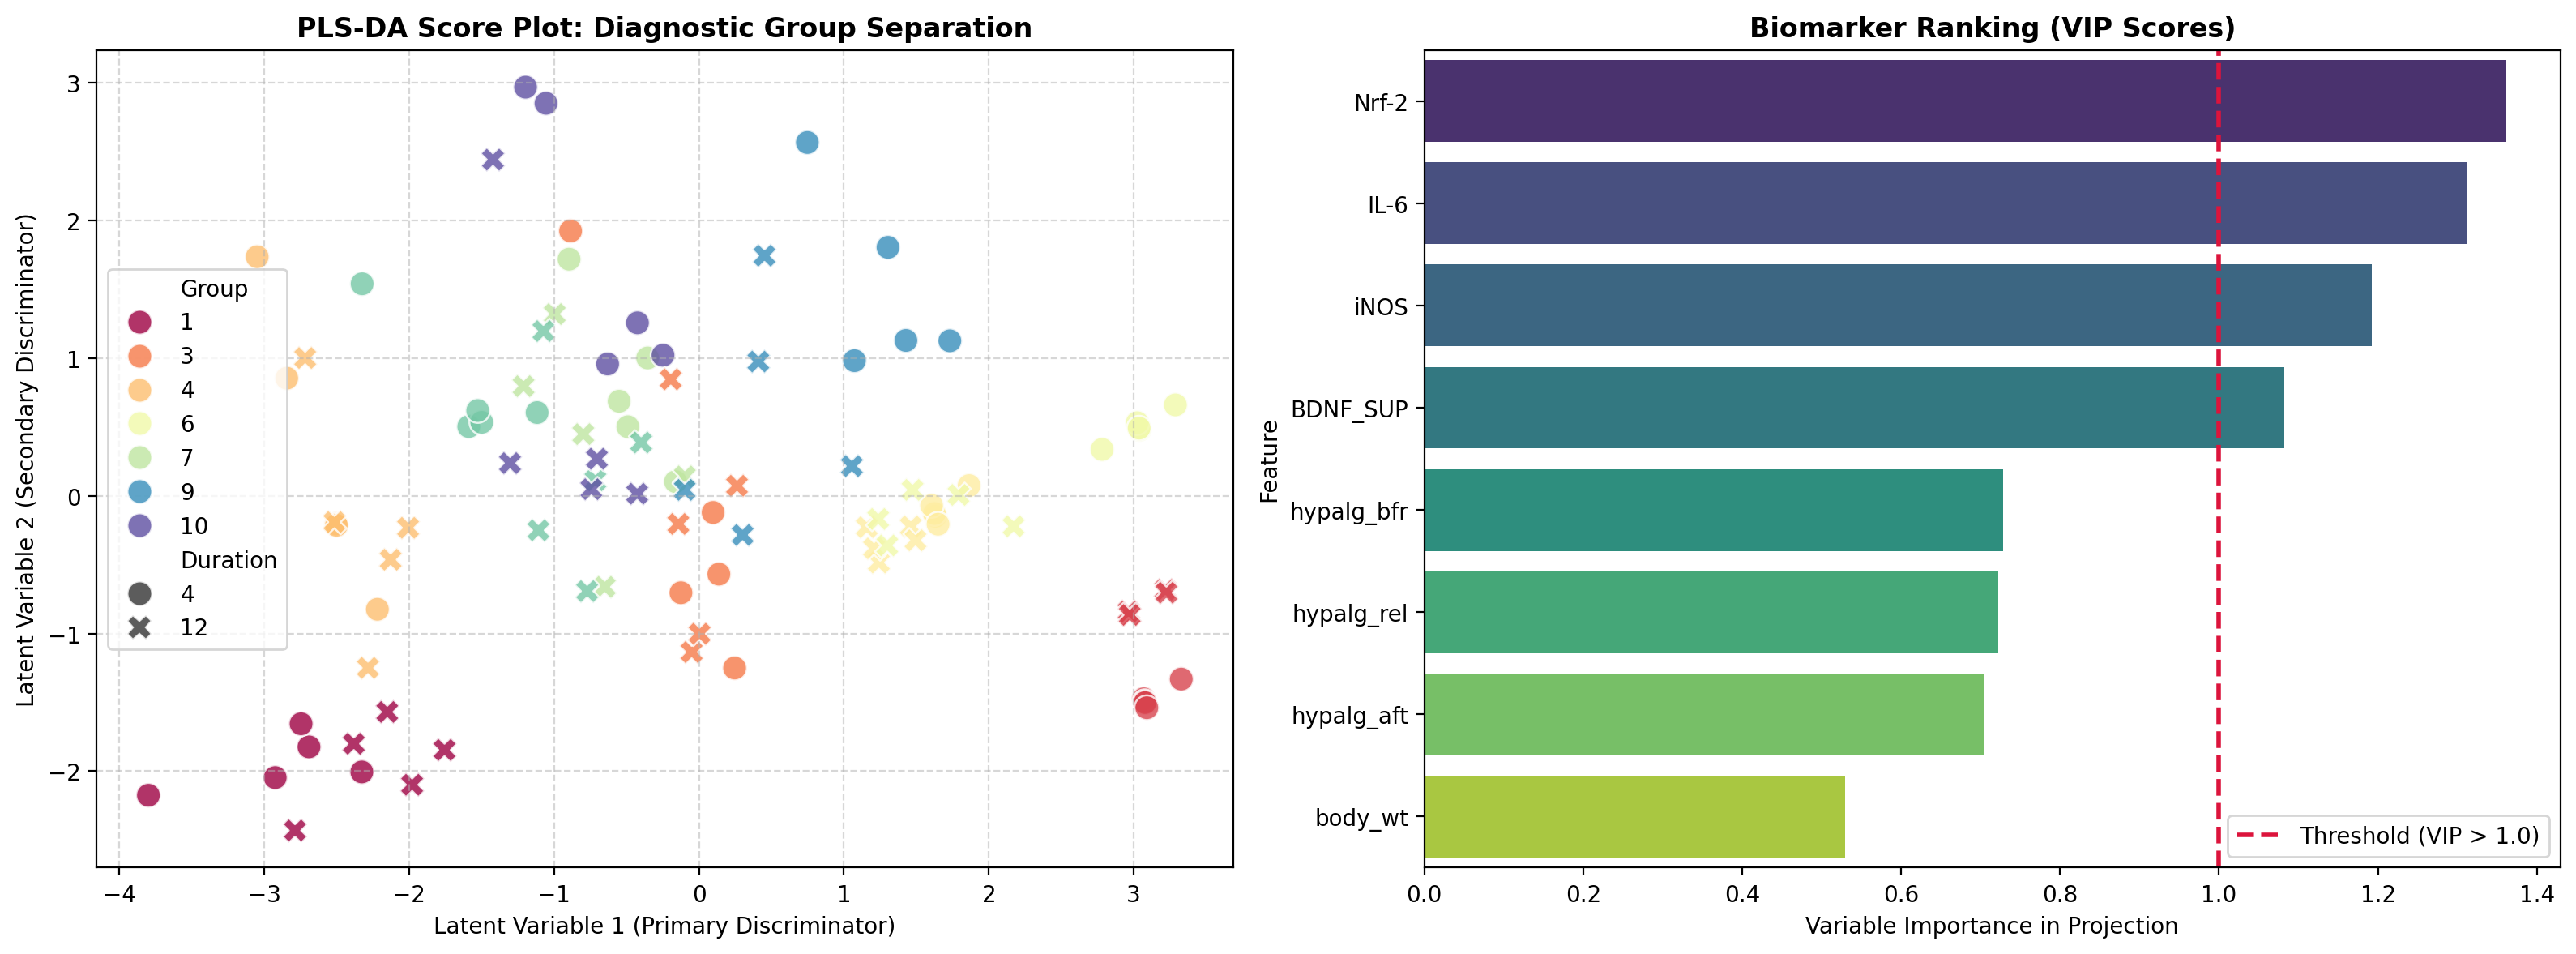

--- Final VIP Diagnostic Ranking ---
      Feature       VIP
7       Nrf-2  1.361650
5        IL-6  1.312784
6        iNOS  1.192244
4    BDNF_SUP  1.082466
1  hypalg_bfr  0.728130
3  hypalg_rel  0.722481
2  hypalg_aft  0.704596
0     body_wt  0.529830


In [ ]:
from sklearn.cross_decomposition import PLSRegression

def calculate_vip(model):
    """
    Calculates the Variable Importance in Projection (VIP) score for PLS-DA.
    Fixed to handle multi-class targets and dimensionality errors.
    """
    t = model.x_scores_
    w = model.x_weights_
    q = model.y_loadings_
    
    p, h = w.shape
    vips = np.zeros((p,))
    
    # Calculate Explained Variance in Y per component (s)
    # For PLS2 (multi-target), we take the diagonal of the covariance matrix
    s = np.diag(t.T @ t @ q.T @ q) 
    total_s = np.sum(s)
    
    for i in range(p):
        # Calculate weight contribution across all components
        weight = np.array([(w[i, j] / np.linalg.norm(w[:, j]))**2 for j in range(h)])
        
        # FIX: Use np.dot or .item() to ensure we assign a scalar, not a sequence
        vips[i] = np.sqrt(p * np.dot(s, weight) / total_s)
        
    return vips

# 1. Feature Selection (X)
# We include the most relevant diagnostic markers based on our previous LMM/CCA
features_x = [
    'body_wt', 'hypalg_bfr', 'hypalg_aft', 'hypalg_rel', 
    'BDNF_SUP', 'IL-6', 'iNOS', 'Nrf-2'
]

# 2. Target Encoding (Y)
# One-hot encode the 10 groups to perform PLS2 (Discriminant Analysis)
Y_dummy = pd.get_dummies(df['group_id']).values
X_raw = df[features_x].values

# 3. Pre-processing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 4. Fit PLS-DA Model (2 Components for optimal visualization)
plsda = PLSRegression(n_components=2)
plsda.fit(X_scaled, Y_dummy)

# 5. Extract Diagnostic Scores
scores = pd.DataFrame(plsda.x_scores_, columns=['LV1', 'LV2'])
scores['Group'] = df['group_id'].values
scores['Duration'] = df['study_duration'].values

# 6. Calculate VIP Scores using the fixed function
vips = calculate_vip(plsda)
vip_df = pd.DataFrame({'Feature': features_x, 'VIP': vips}).sort_values(by='VIP', ascending=False)

# --- SCIENTIFIC VISUALIZATION ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Diagnostic Score Plot
# This shows how the brain/behavior "Signature" separates the groups
sns.scatterplot(data=scores, x='LV1', y='LV2', hue='Group', style='Duration', 
                s=120, palette='Spectral', ax=ax1, edgecolor='w', alpha=0.8)
ax1.set_title('PLS-DA Score Plot: Diagnostic Group Separation', fontweight='bold')
ax1.set_xlabel('Latent Variable 1 (Primary Discriminator)')
ax1.set_ylabel('Latent Variable 2 (Secondary Discriminator)')
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot B: VIP Biomarker Ranking
sns.barplot(data=vip_df, x='VIP', y='Feature', hue='Feature', 
            palette='viridis', ax=ax2, legend=False)
ax2.axvline(x=1.0, color='crimson', linestyle='--', linewidth=2, label='Threshold (VIP > 1.0)')
ax2.set_title('Biomarker Ranking (VIP Scores)', fontweight='bold')
ax2.set_xlabel('Variable Importance in Projection')
ax2.legend()

plt.tight_layout()
plt.show()

print("--- Final VIP Diagnostic Ranking ---")
print(vip_df)

In [ ]:
scores.to_csv( os.path.join('..','figures','PLS-DA_scores.csv') , index=False )
vip_df.to_csv( os.path.join('..','figures','PLS-DA_vip_df.csv') , index=False )

## Recursive Feature Elimination (RFE) with Random Forest

--- Predictive Performance ---
Mean R^2 Score (LOGO-CV): -440.1334
Standard Deviation: 1294.5018


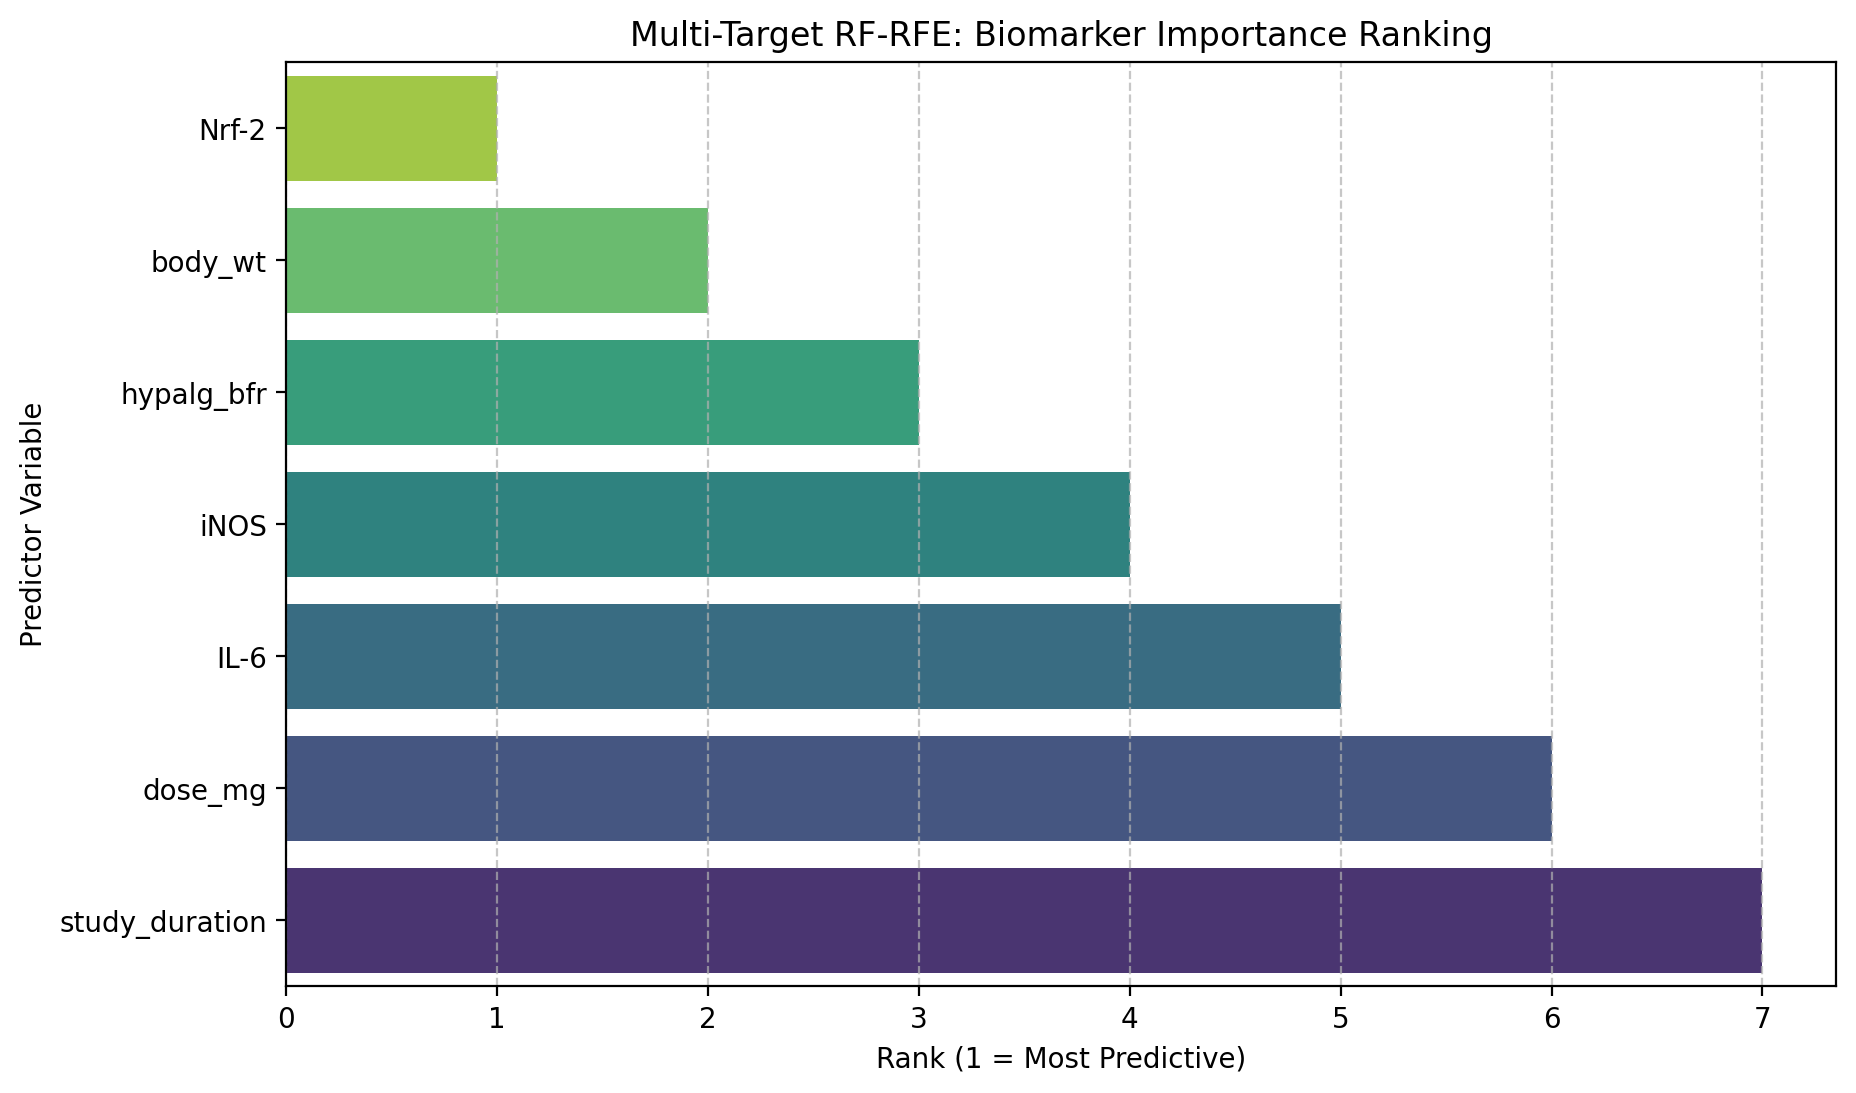


--- Final Predictive Ranking ---
          Feature  Rank
5           Nrf-2     1
0         body_wt     2
1      hypalg_bfr     3
4            iNOS     4
3            IL-6     5
2         dose_mg     6
6  study_duration     7


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import LeaveOneGroupOut

# 1. Feature & Target Selection
# X: Predictors (Excluding the targets themselves and ID columns)
features_x = ['body_wt', 'hypalg_bfr', 'dose_mg', 'IL-6', 'iNOS', 'Nrf-2', 'study_duration']
X = df[features_x].copy()

# Y: Multi-Target (Behavioral + Molecular)
targets_y = ['hypalg_aft', 'BDNF_SUP']
Y = df[targets_y].copy()

# 2. Pre-processing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Initialize Multi-Target Random Forest
# RF natively supports multi-output regression
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 4. Recursive Feature Elimination (RFE)
# We want to rank all features from most to least important
rfe = RFE(estimator=rf, n_features_to_select=1, step=1)
rfe.fit(X_scaled, Y)

# 5. Extract Rankings
ranking_df = pd.DataFrame({
    'Feature': features_x,
    'Rank': rfe.ranking_
}).sort_values(by='Rank')

# 6. Cross-Validation (Leave-One-Group-Out)
# To prove the model's predictive power
logo = LeaveOneGroupOut()
scores = []

for train_idx, test_idx in logo.split(X_scaled, Y, groups=df['group_id']):
    rf.fit(X_scaled[train_idx], Y.iloc[train_idx])
    score = rf.score(X_scaled[test_idx], Y.iloc[test_idx])
    scores.append(score)

print(f"--- Predictive Performance ---")
print(f"Mean R^2 Score (LOGO-CV): {np.mean(scores):.4f}")
print(f"Standard Deviation: {np.std(scores):.4f}")

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
sns.barplot(data=ranking_df, x='Rank', y='Feature', hue='Feature', palette='viridis_r')
plt.title('Multi-Target RF-RFE: Biomarker Importance Ranking')
plt.xlabel('Rank (1 = Most Predictive)')
plt.ylabel('Predictor Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\n--- Final Predictive Ranking ---")
print(ranking_df)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import LeaveOneGroupOut

# 1. Setup Data
features_x = ['body_wt', 'hypalg_bfr', 'dose_mg', 'IL-6', 'iNOS', 'Nrf-2', 'study_duration']
targets_y = ['hypalg_aft', 'BDNF_SUP']

X = df[features_x].values
Y = df[targets_y].values
groups = df['group_id'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Define the Base Model
# We wrap RF in MultiOutputRegressor to ensure targets are handled jointly
base_rf = RandomForestRegressor(random_state=42)
multi_rf = MultiOutputRegressor(base_rf)

# 3. Define the Bayesian Search Space
# We focus on parameters that control "Generalization"
search_spaces = {
    'estimator__n_estimators': skopt.space.Integer(1, 100, prior='log-uniform'),
    'estimator__max_depth': skopt.space.Integer(1, 16, prior='log-uniform'),
    'estimator__min_samples_leaf': skopt.space.Integer(1, 16, prior='log-uniform'),
    'estimator__max_features': skopt.space.Integer(1, 16, prior='log-uniform')
}

# 4. Initialize BayesSearchCV with LOGO-CV
# This is the "Smart" search
opt = skopt.BayesSearchCV(
    estimator=multi_rf,
    search_spaces=search_spaces,
    n_iter=32,            # Number of "tastes" the Bayesian chef takes
    cv=LeaveOneGroupOut(), # Crucial: Tuning for group-level generalizability
    n_jobs=-1,
    random_state=42,
    scoring='r2'
)

# 5. Execute Tuning
print("Starting Bayesian Hyperparameter Tuning...")

# Initialize our safe callback
on_step = SafeTqdmCallback(n_iter=opt.n_iter, desc="Optimizing Random Forest")
# pbar = tqdm.tqdm(total=opt.n_iter, desc="Optimizing Random Forest", ncols=150)
# def on_step(optim_result):
#     pbar.update(1)
#     return False  # Return True to stop the search early if needed

# Run the fit with n_jobs=-1 safely
opt.fit(X, Y, callback=on_step, groups=groups)
# pbar.close()

# 6. Extract Results
best_params = opt.best_params_
best_score = opt.best_score_

print(f"\n--- Bayesian Tuning Results ---")
print(f"Best LOGO-CV R^2 Score: {best_score:.4f}")
print(f"Best Parameters: {best_params}")

# 7. Final Model Evaluation
# We run one last check to see if we improved from the -440 baseline
tuned_model = opt.best_estimator_
final_scores = []
logo = LeaveOneGroupOut()

for train_idx, test_idx in logo.split(X_scaled, Y, groups=groups):
    tuned_model.fit(X_scaled[train_idx], Y[train_idx])
    final_scores.append(tuned_model.score(X_scaled[test_idx], Y[test_idx]))

print(f"\nTuned Mean R^2: {np.mean(final_scores):.4f}")

Starting Bayesian Hyperparameter Tuning...


Optimizing Random Forest: 100%|███████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:09<00:00,  3.33it/s]



--- Bayesian Tuning Results ---
Best LOGO-CV R^2 Score: -198.3418
Best Parameters: OrderedDict({'estimator__max_depth': 5, 'estimator__max_features': 13, 'estimator__min_samples_leaf': 5, 'estimator__n_estimators': 49})

Tuned Mean R^2: -199.2345


## Unsupervised Clustering (Hierarchical or K-Means)

Text(0.55, 1.02, 'Global Phenotypic Landscape of Nicotine Withdrawal & Recovery')

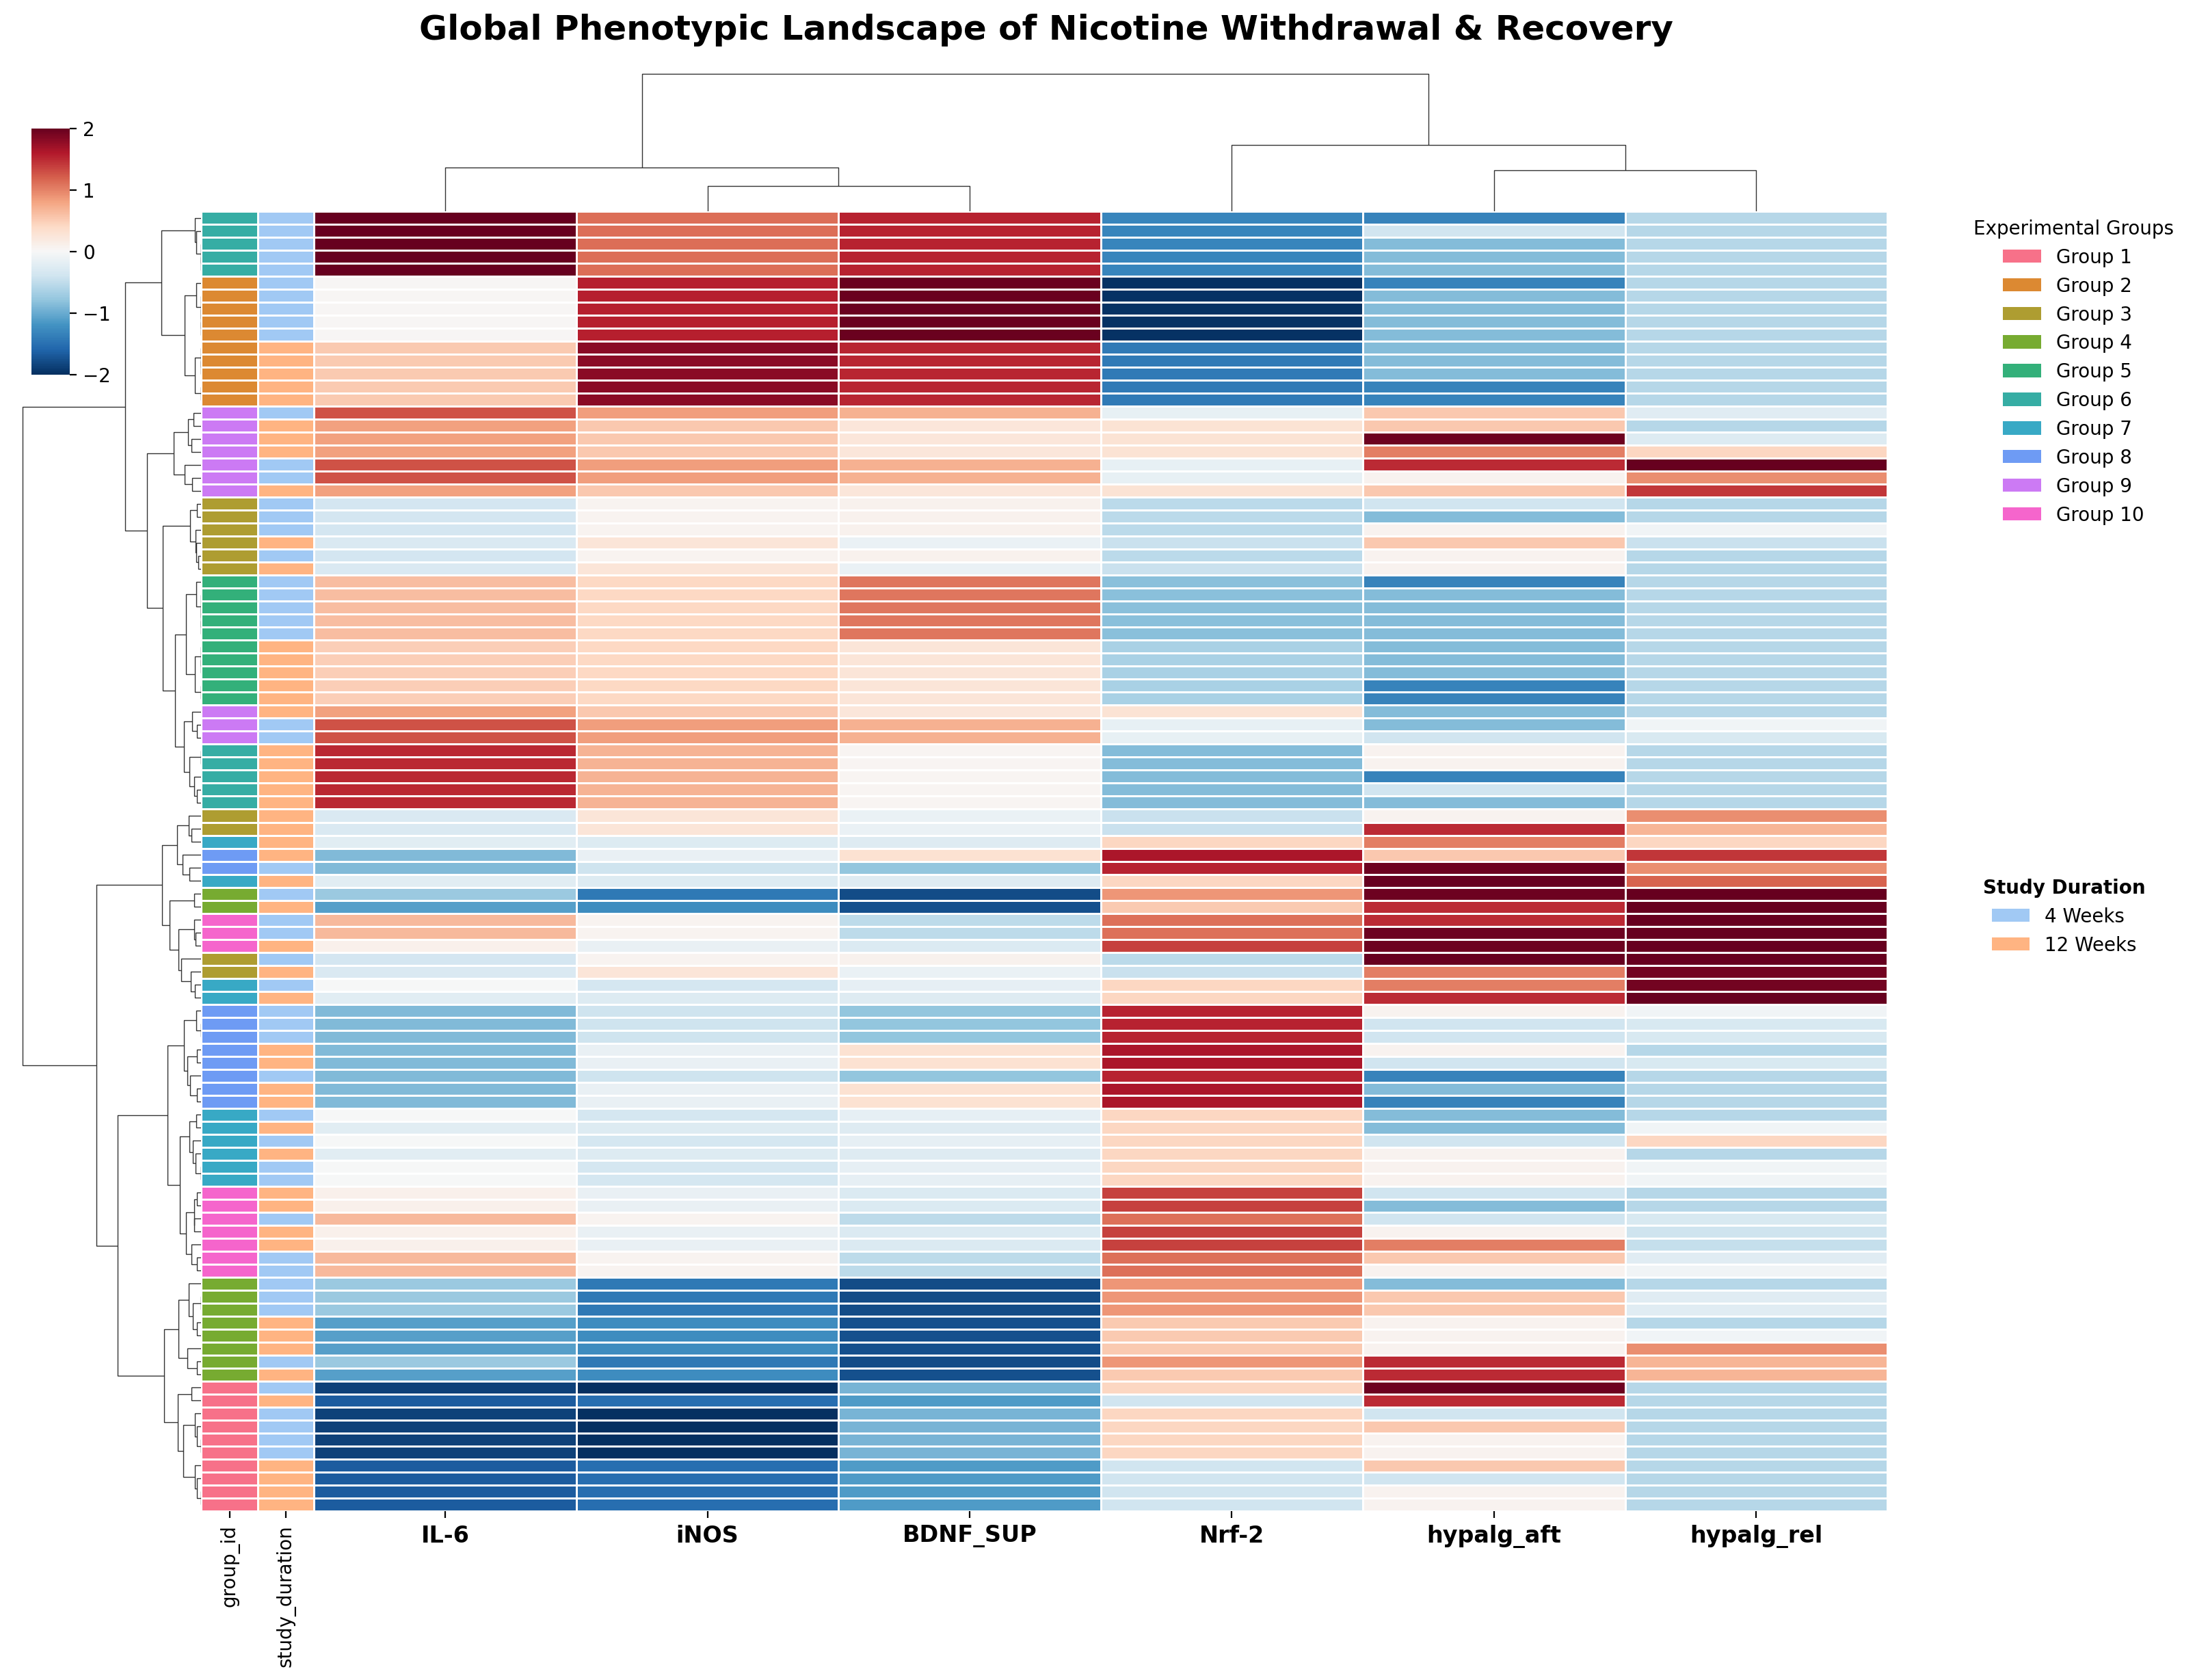

In [87]:
from matplotlib.patches import Patch
from matplotlib.legend import Legend

# 1. Setup Data
cluster_cols = ['Nrf-2', 'IL-6', 'iNOS', 'BDNF_SUP', 'hypalg_aft', 'hypalg_rel']
df_clean = df.copy().reset_index(drop=True)
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_clean[cluster_cols]), columns=cluster_cols)

# 2. Color Mapping
group_pal = sns.color_palette("husl", len(df_clean['group_id'].unique()))
group_lut = dict(zip(sorted(df_clean['group_id'].unique()), group_pal))
group_colors = df_clean['group_id'].map(group_lut)

dur_pal = ["#A1C9F4", "#FFB482"] 
dur_lut = dict(zip(sorted(df_clean['study_duration'].unique()), dur_pal))
dur_colors = df_clean['study_duration'].map(dur_lut)
row_colors = pd.concat([group_colors, dur_colors], axis=1)

# 3. Generate Clustermap
plt.rcParams['font.family'] = 'sans-serif'
g = sns.clustermap(df_scaled, 
                   method='ward', 
                   metric='euclidean',
                   row_colors=row_colors,
                   cmap='RdBu_r', 
                   center=0, 
                   vmax=2.0, vmin=-2.0,
                   linewidths=0.5, 
                   figsize=(14, 12),
                   dendrogram_ratio=(0.1, 0.1),
                   cbar_pos=(0.02, 0.8, 0.02, 0.15),
                   yticklabels=False)

# 4. FIXED LEGENDS (Pushed Outside)
# Legend for Experimental Groups
group_legends = [Patch(facecolor=group_lut[g_id], label=f'Group {g_id}') for g_id in sorted(group_lut)]
leg1 = g.ax_heatmap.legend(handles=group_legends, title="Experimental Groups", 
                           bbox_to_anchor=(1.05, 1), loc='upper left', 
                           borderaxespad=0., frameon=False, 
                           # title_fontweight='bold'
                           )

# Legend for Study Duration
dur_legends = [Patch(facecolor=dur_lut[d], label=f'{d} Weeks') for d in sorted(dur_lut)]
# Create the second legend manually to avoid the ValueError
leg2 = Legend(g.ax_heatmap, handles=dur_legends, labels=[f'{d} Weeks' for d in sorted(dur_lut)],
              title="Study Duration", bbox_to_anchor=(1.05, 0.5), 
              loc='upper left', frameon=False)
leg2.set_title("Study Duration", prop={'weight':'bold'})

# Add the second artist back to the axes
g.ax_heatmap.add_artist(leg2)

# 5. Final Formatting
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize=12, fontweight='bold')
plt.suptitle('Global Phenotypic Landscape of Nicotine Withdrawal & Recovery', 
             y=1.02, x=0.55, fontsize=18, fontweight='bold')

In [ ]:
# ==========================================
# DATA EXTRACTION FOR EXCEL EXPORT
# ==========================================

# g.data2d contains the exact dataframe as displayed in the heatmap 
# (rows and columns reordered by the dendrograms)
df_clustered = g.data2d.copy()

# Extract the reordered row indices to match our metadata (Group and Duration)
row_indices = g.dendrogram_row.reordered_ind

# Insert the metadata at the beginning of the dataframe so you know which row is which
df_clustered.insert(0, 'Study_Duration', df_clean['study_duration'].iloc[row_indices].values)
df_clustered.insert(0, 'Group_ID', df_clean['group_id'].iloc[row_indices].values)

# Save the reordered data to a CSV file
csv_filename = 'Phenotypic_Clustered_Data.csv'
df_clustered.to_csv( os.path.join('..','figures',csv_filename), index=False)

# # Save a High-Resolution image of the plot (Required for Excel Dendrogram)
# img_filename = 'High_Res_Dendrogram.png'
# g.savefig(img_filename, dpi=300, bbox_inches='tight')

In [93]:
import plotly.graph_objects as go


# 1. Feature Selection & Data Preparation
radar_cols = ['Nrf-2', 'IL-6', 'iNOS', 'BDNF_SUP', 'hypalg_aft', 'hypalg_rel']

# We calculate the Mean Z-score per group to ensure fair comparison
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[radar_cols]), columns=radar_cols)
df_scaled['group_id'] = df['group_id'].values

# Group by ID and get the mean profile
df_radar = df_scaled.groupby('group_id').mean().reset_index()

# 2. Define the Plotly Figure
fig = go.Figure()

# Custom color palette for 10 groups (Scientific husl-like palette)
colors = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', 
    '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe'
]

# 3. Add each group as a trace
for i, row in df_radar.iterrows():
    g_id = int(row['group_id'])
    
    # Radar charts must be "closed" (the last point connects back to the first)
    r_values = row[radar_cols].tolist()
    r_values += [r_values[0]]
    theta_labels = radar_cols + [radar_cols[0]]
    
    fig.add_trace(go.Scatterpolar(
        r=r_values,
        theta=theta_labels,
        fill='toself',
        name=f'Group {g_id}',
        line=dict(color=colors[i], width=2),
        opacity=0.6,
        # Initially hide intermediate groups to keep the plot clean
        visible=True if g_id in [1, 9, 10] else 'legendonly'
    ))

# 4. High-End Scientific Layout
fig.update_layout(
    title=dict(
        text="<b>Comparative Phenotypic Fingerprints: Nicotine Withdrawal & Recovery</b>",
        x=0.5, y=0.95, font=dict(size=20, family="Arial")
    ),
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[-2, 2], # Z-score range
            tickfont=dict(size=10),
            gridcolor="rgba(0,0,0,0.1)"
        ),
        angularaxis=dict(
            tickfont=dict(size=12, family="Arial", color="black"),
            gridcolor="rgba(0,0,0,0.1)",
            rotation=90, # Rotates the start point to the top
            direction="clockwise"
        ),
        bgcolor="white"
    ),
    showlegend=True,
    legend=dict(
        title="<b>Experimental Groups</b><br><i>(Click to Toggle)</i>",
        orientation="v",
        yanchor="middle",
        y=0.5,
        xanchor="left",
        x=1.1
    ),
    margin=dict(l=80, r=150, t=100, b=80),
    paper_bgcolor="white",
)

fig.show()

In [ ]:
# ==========================================
# DATA EXTRACTION FOR EXCEL RADAR PLOT
# ==========================================

# Create a copy of the aggregated radar data
df_excel_radar = df_radar.copy()

# Format the group names nicely for Excel column headers
df_excel_radar['group_id'] = 'Group ' + df_excel_radar['group_id'].astype(int).astype(str)

# Set the group_id as the index and transpose the dataframe
# This makes Features the rows and Groups the columns (Excel's preferred format)
df_excel_radar = df_excel_radar.set_index('group_id').T

# Name the index column for clarity
df_excel_radar.index.name = 'Feature'

# Export to CSV
csv_radar_filename = 'Phenotypic_Radar_Data.csv'
df_excel_radar.to_csv(os.path.join('..','figures',csv_radar_filename))

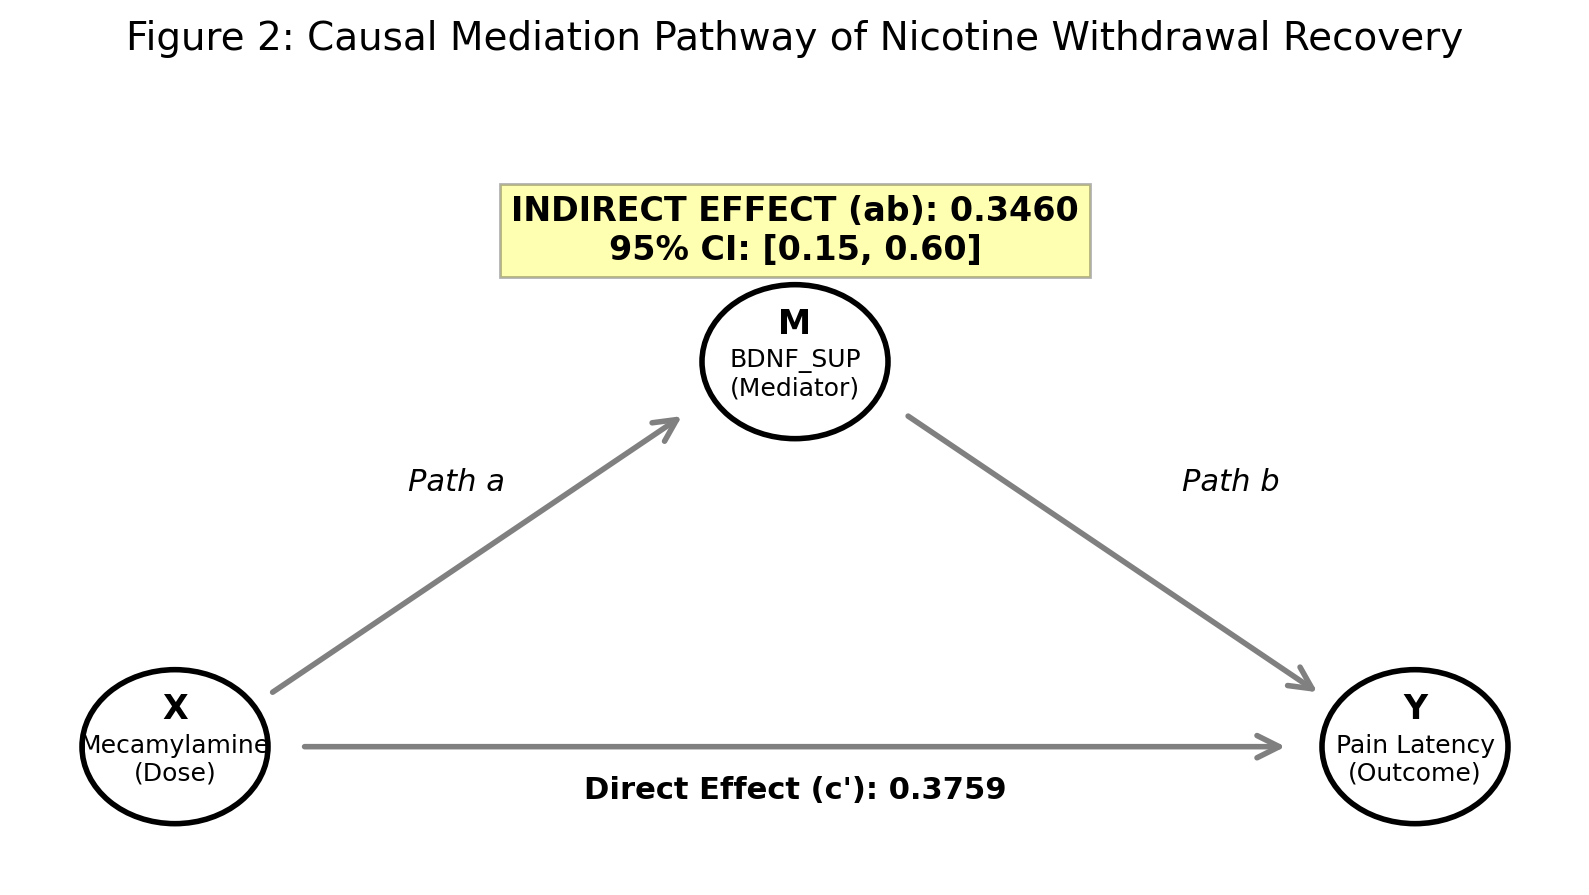

In [44]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_mediation_diagram(c_prime, ab, ci):
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Define node positions
    pos = {'X': (1, 1), 'M': (5, 4), 'Y': (9, 1)}
    
    # Draw Nodes (Circles)
    for label, (x, y) in pos.items():
        circle = patches.Circle((x, y), 0.6, color='white', ec='black', lw=2)
        ax.add_patch(circle)
        name = "Mecamylamine\n(Dose)" if label == 'X' else "BDNF_SUP\n(Mediator)" if label == 'M' else "Pain Latency\n(Outcome)"
        ax.text(x, y, f"{label}\n\n", ha='center', va='center', fontweight='bold', fontsize=12)
        ax.text(x, y-0.1, name, ha='center', va='center', fontsize=9)

    # Draw Arrows
    arrow_props = dict(arrowstyle='->', lw=2, mutation_scale=20, color='gray')
    ax.annotate('', xy=(4.3, 3.6), xytext=(1.6, 1.4), arrowprops=arrow_props) # Path a
    ax.annotate('', xy=(8.4, 1.4), xytext=(5.7, 3.6), arrowprops=arrow_props) # Path b
    ax.annotate('', xy=(8.2, 1.0), xytext=(1.8, 1.0), arrowprops=arrow_props) # Path c'

    # Add Coefficients and Labels
    # Path a (Dose -> BDNF) - We assume a positive relationship based on pharmacology
    ax.text(2.5, 3.0, "Path a", fontsize=11, fontstyle='italic')
    
    # Path b (BDNF -> Pain)
    ax.text(7.5, 3.0, "Path b", fontsize=11, fontstyle='italic')
    
    # Direct Effect (c')
    ax.text(5, 0.6, f"Direct Effect (c'): {c_prime:.4f}", ha='center', fontsize=11, fontweight='bold')
    
    # Indirect Effect (ab) - The "Mechanism"
    ax.text(5, 4.8, f"INDIRECT EFFECT (ab): {ab:.4f}\n95% CI: [{ci[0]:.2f}, {ci[1]:.2f}]", 
            ha='center', bbox=dict(facecolor='yellow', alpha=0.3), fontsize=12, fontweight='bold')

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.axis('off')
    plt.title("Figure 2: Causal Mediation Pathway of Nicotine Withdrawal Recovery", fontsize=14, pad=20)
    plt.show()

# Use the values from your Robust Mediation Output
plot_mediation_diagram(c_prime=0.3759, ab=0.3460, ci=[0.1504, 0.5986])

<>:95: SyntaxWarning:

invalid escape sequence '\D'

<>:95: SyntaxWarning:

invalid escape sequence '\D'

/tmp/ipykernel_345571/2383769291.py:95: SyntaxWarning:

invalid escape sequence '\D'



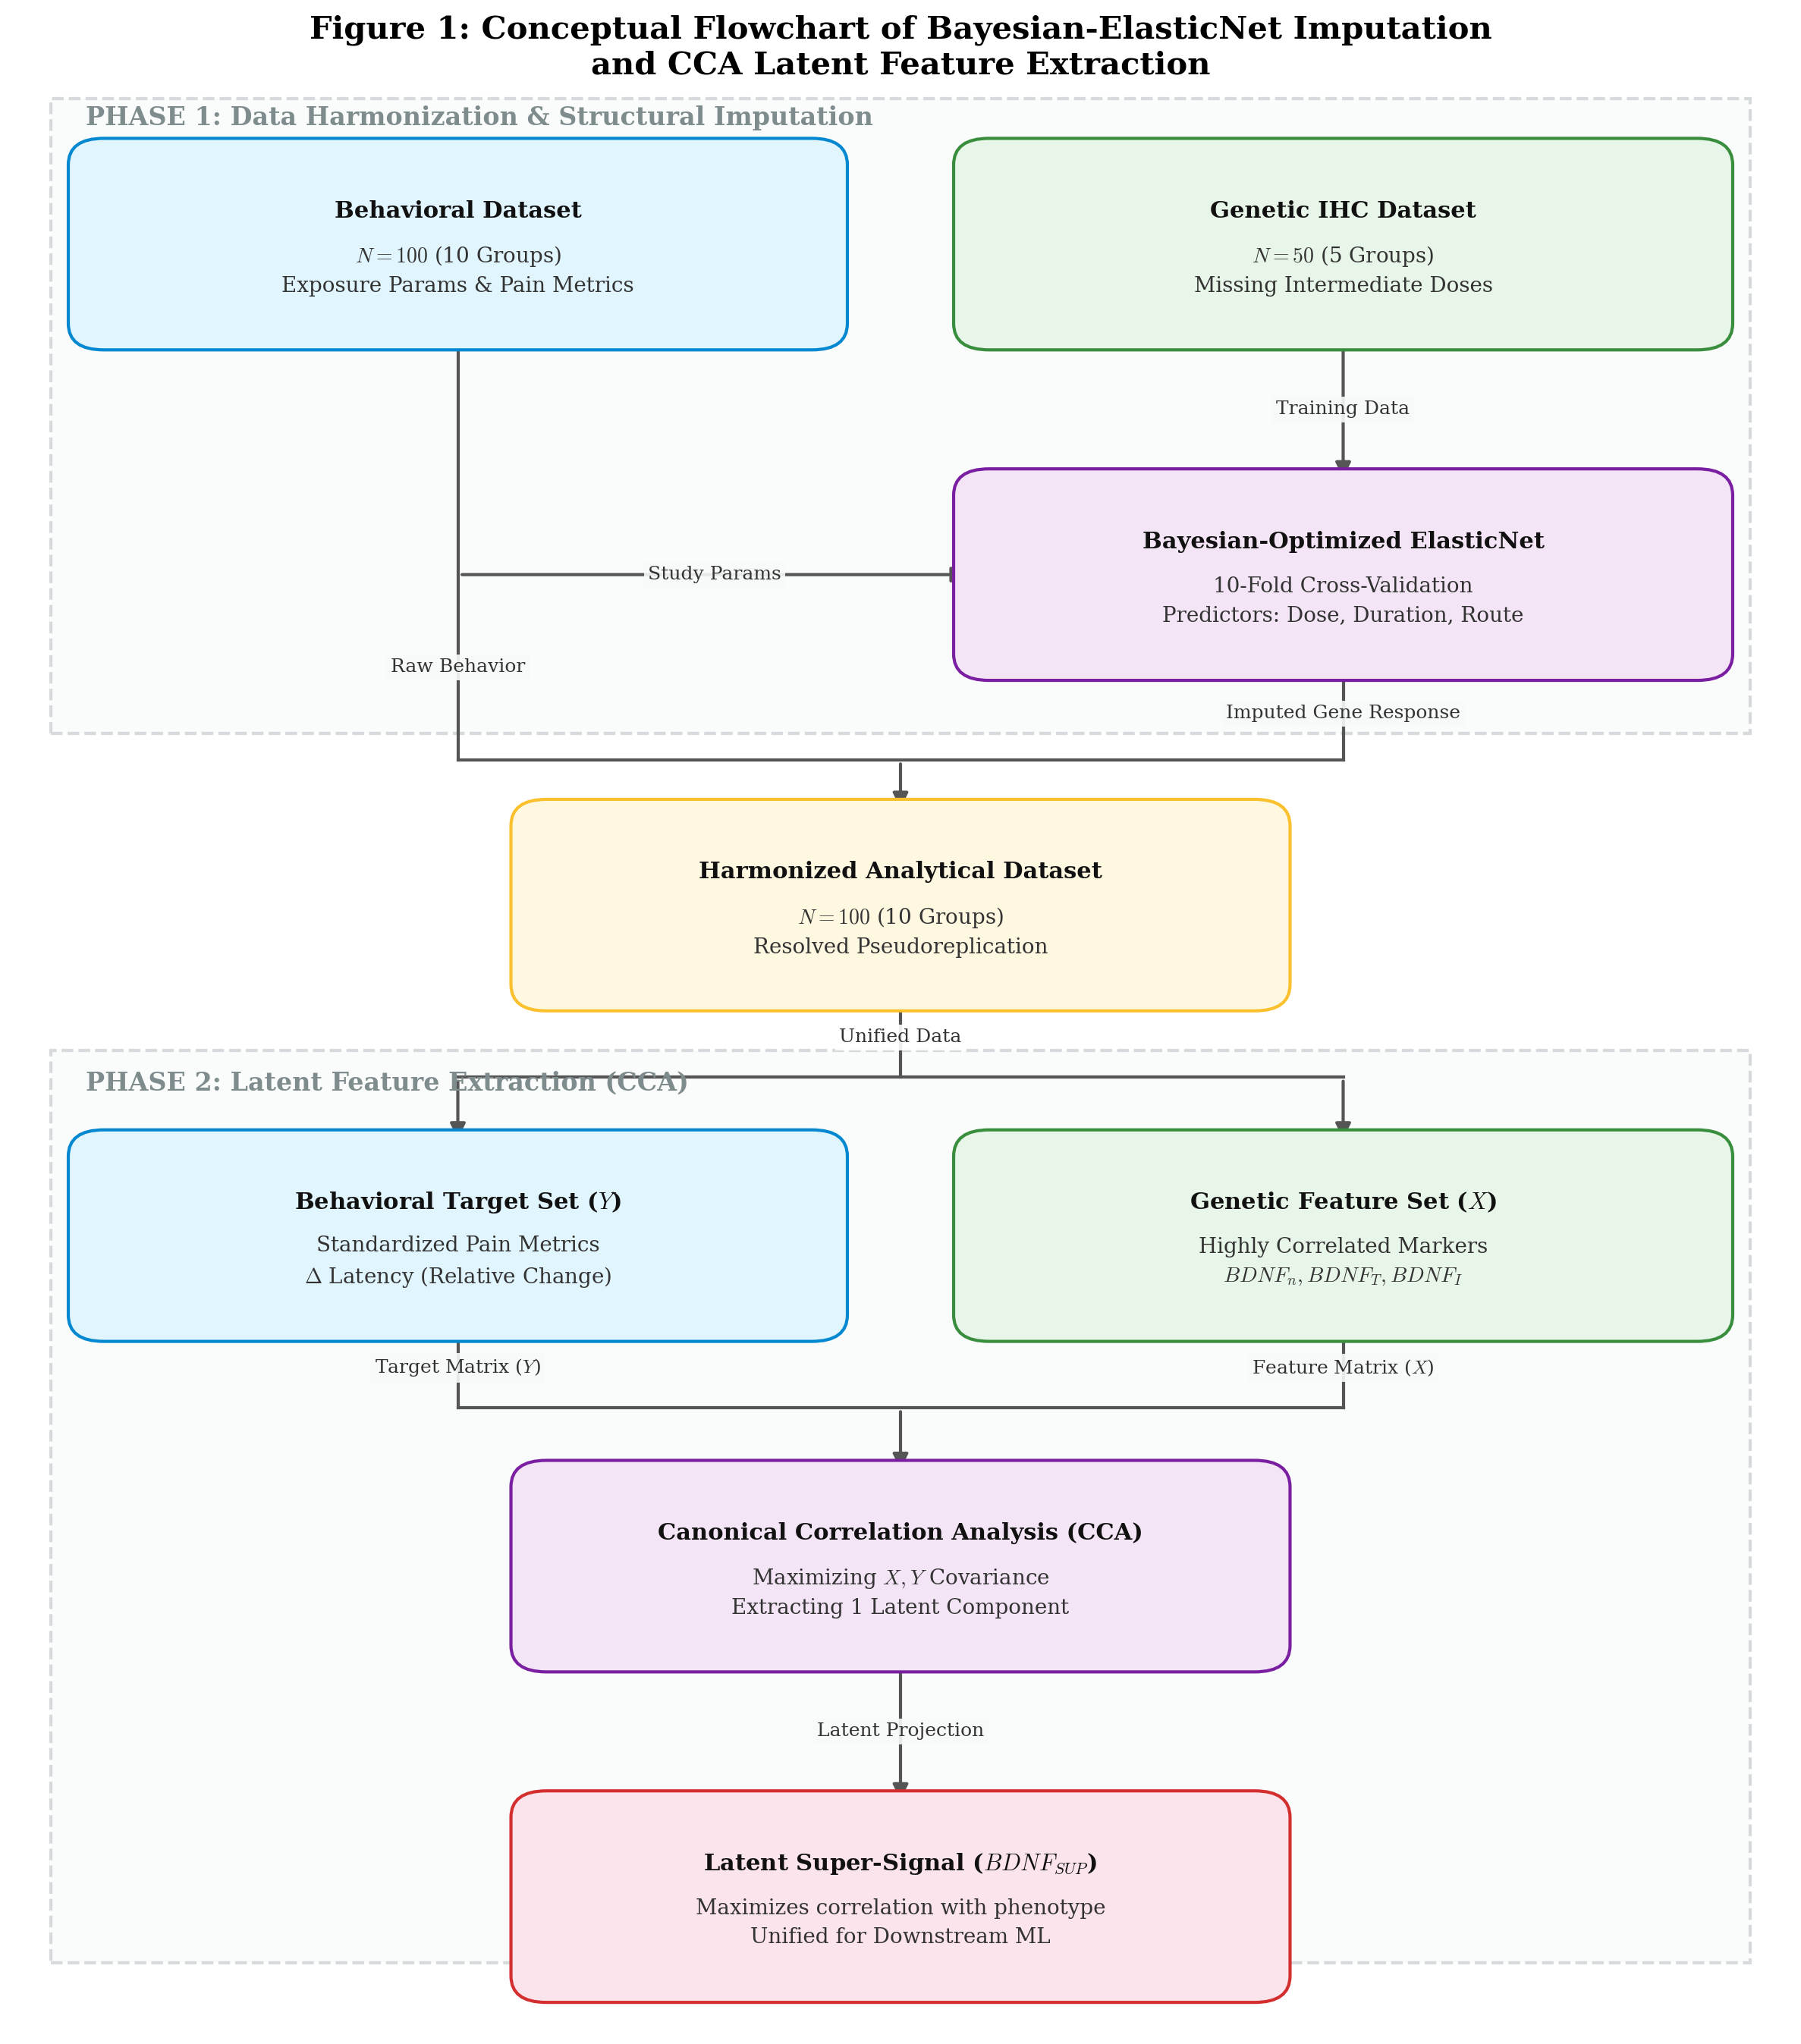

In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==========================================
# 1. SETUP AESTHETICS & LATEX-STYLE FONTS
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm", # Computer Modern for LaTeX math styling
    "axes.titlesize": 16,
    "font.size": 11
})

fig, ax = plt.subplots(figsize=(12, 14))
ax.set_xlim(0, 10)
ax.set_ylim(-3, 12)
ax.axis('off') # Hide grid and axes for clean flowchart

# ==========================================
# 2. COLOR PALETTES
# ==========================================
# Professional pastel palette with darker edges for contrast
C_BEHAVIOR = '#E1F5FE'  # Light Blue
E_BEHAVIOR = '#0288D1'
C_GENETIC = '#E8F5E9'   # Light Green
E_GENETIC = '#388E3C'
C_MODEL = '#F3E5F5'     # Light Purple
E_MODEL = '#7B1FA2'
C_HARMONIZED = '#FFF8E1'# Light Yellow
E_HARMONIZED = '#FBC02D'
C_OUTPUT = '#FCE4EC'    # Light Pink
E_OUTPUT = '#D32F2F'
C_BG = '#F8F9F9'        # Very light gray for phase backgrounds

# ==========================================
# 3. HELPER FUNCTIONS
# ==========================================
def draw_box(ax, x, y, width, height, title, body, facecolor, edgecolor):
    """Draws a rounded rectangle with a bold title and regular body text."""
    box = mpatches.FancyBboxPatch(
        (x - width/2, y - height/2), width, height,
        boxstyle="round,pad=0.1,rounding_size=0.2",
        facecolor=facecolor, edgecolor=edgecolor, linewidth=1.5, zorder=3
    )
    ax.add_patch(box)
    ax.text(x, y + 0.25, title, ha='center', va='center', 
            fontsize=11, fontweight='bold', zorder=4, color='#111111')
    ax.text(x, y - 0.20, body, ha='center', va='center', 
            fontsize=10, zorder=4, linespacing=1.5, color='#333333')

def draw_label(ax, x, y, text, rotation=0, bg_color=C_BG):
    """Draws text over lines with a background box to prevent strike-through."""
    ax.text(x, y, text, ha='center', va='center', fontsize=9, color='#333333', 
            rotation=rotation, zorder=5, 
            bbox=dict(facecolor=bg_color, edgecolor='none', pad=2, alpha=0.9))

# ==========================================
# 4. DRAW BACKGROUND PANELS (PHASES)
# ==========================================
# Phase 1 Background
rect1 = mpatches.Rectangle((0.2, 6.8), 9.6, 4.8, linewidth=1.5, edgecolor='#BDC3C7', 
                           facecolor=C_BG, alpha=0.6, zorder=0, linestyle='--')
ax.add_patch(rect1)
ax.text(0.4, 11.4, "PHASE 1: Data Harmonization & Structural Imputation", 
        fontsize=12, fontweight='bold', color='#7F8C8D', ha='left')

# Phase 2 Background
rect2 = mpatches.Rectangle((0.2, -2.5), 9.6, 6.9, linewidth=1.5, edgecolor='#BDC3C7', 
                           facecolor=C_BG, alpha=0.6, zorder=0, linestyle='--')
ax.add_patch(rect2)
ax.text(0.4, 4.1, "PHASE 2: Latent Feature Extraction (CCA)", 
        fontsize=12, fontweight='bold', color='#7F8C8D', ha='left')

# ==========================================
# 5. DRAW NODE BOXES
# ==========================================
W, H = 4.2, 1.4 # Standard Box Width and Height

# Level 1: Raw Data
draw_box(ax, 2.5, 10.5, W, H, "Behavioral Dataset", 
         "$N=100$ (10 Groups)\nExposure Params & Pain Metrics", C_BEHAVIOR, E_BEHAVIOR)
draw_box(ax, 7.5, 10.5, W, H, "Genetic IHC Dataset", 
         "$N=50$ (5 Groups)\nMissing Intermediate Doses", C_GENETIC, E_GENETIC)

# Level 2: Imputation Model
draw_box(ax, 7.5, 8.0, W, H, "Bayesian-Optimized ElasticNet", 
         "10-Fold Cross-Validation\nPredictors: Dose, Duration, Route", C_MODEL, E_MODEL)

# Level 3: Harmonized Data (The Bridge)
draw_box(ax, 5.0, 5.5, W, H, "Harmonized Analytical Dataset", 
         "$N=100$ (10 Groups)\nResolved Pseudoreplication", C_HARMONIZED, E_HARMONIZED)

# Level 4: Feature Split
draw_box(ax, 2.5, 3.0, W, H, "Behavioral Target Set ($Y$)", 
         "Standardized Pain Metrics\n$\Delta$ Latency (Relative Change)", C_BEHAVIOR, E_BEHAVIOR)
draw_box(ax, 7.5, 3.0, W, H, "Genetic Feature Set ($X$)", 
         "Highly Correlated Markers\n$BDNF_n, BDNF_T, BDNF_I$", C_GENETIC, E_GENETIC)

# Level 5: CCA Model
draw_box(ax, 5.0, 0.5, W, H, "Canonical Correlation Analysis (CCA)", 
         "Maximizing $X, Y$ Covariance\nExtracting 1 Latent Component", C_MODEL, E_MODEL)

# Level 6: Final Output
draw_box(ax, 5.0, -2.0, W, H, "Latent Super-Signal ($BDNF_{SUP}$)", 
         "Maximizes correlation with phenotype\nUnified for Downstream ML", C_OUTPUT, E_OUTPUT)

# ==========================================
# 6. DRAW MANHATTAN ROUTING ARROWS
# ==========================================
line_opts = dict(color='#555555', lw=1.5, zorder=1)
arrow_opts = dict(arrowstyle="-|>", color="#555555", lw=1.5, mutation_scale=15)

# B2 to B3 (Genetic to Imputation)
ax.annotate("", xy=(7.5, 8.7), xytext=(7.5, 9.8), arrowprops=arrow_opts, zorder=2)
draw_label(ax, 7.5, 9.25, "Training Data", rotation=00)

# B1 to B3 (Study Params to Imputation)
ax.plot([2.5, 2.5],[9.8, 6.6], **line_opts) # Main left trunk
ax.annotate("", xy=(5.4, 8.0), xytext=(2.5, 8.0), arrowprops=arrow_opts, zorder=2)
draw_label(ax, 3.95, 8.0, "Study Params")

# B1 & B3 to B4 (Join into Harmonized)
ax.plot([7.5, 7.5],[7.3, 6.6], **line_opts) # Right trunk down
ax.plot([2.5, 7.5], [6.6, 6.6], **line_opts) # Horizontal join
ax.annotate("", xy=(5.0, 6.2), xytext=(5.0, 6.6), arrowprops=arrow_opts, zorder=2)
draw_label(ax, 2.5, 7.3, "Raw Behavior", rotation=00)
draw_label(ax, 7.5, 6.95, "Imputed Gene Response", rotation=00)

# B4 to B5a & B5b (Fork from Harmonized)
ax.plot([5.0, 5.0],[4.8, 4.2], **line_opts) # Center trunk down
ax.plot([2.5, 7.5], [4.2, 4.2], **line_opts) # Horizontal fork
ax.annotate("", xy=(2.5, 3.7), xytext=(2.5, 4.2), arrowprops=arrow_opts, zorder=2)
ax.annotate("", xy=(7.5, 3.7), xytext=(7.5, 4.2), arrowprops=arrow_opts, zorder=2)
draw_label(ax, 5.0, 4.5, "Unified Data", bg_color='white') # White bg because it's in the gap

# B5a & B5b to B6 (Join into CCA)
ax.plot([2.5, 2.5],[2.3, 1.7], **line_opts)
ax.plot([7.5, 7.5],[2.3, 1.7], **line_opts)
ax.plot([2.5, 7.5],[1.7, 1.7], **line_opts)
ax.annotate("", xy=(5.0, 1.2), xytext=(5.0, 1.7), arrowprops=arrow_opts, zorder=2)
draw_label(ax, 2.5, 2.0, "Target Matrix ($Y$)", rotation=00)
draw_label(ax, 7.5, 2.0, "Feature Matrix ($X$)", rotation=00)

# B6 to B7 (CCA to Output)
ax.annotate("", xy=(5.0, -1.3), xytext=(5.0, -0.2), arrowprops=arrow_opts, zorder=2)
draw_label(ax, 5.0, -0.75, "Latent Projection")

# ==========================================
# 7. FINAL RENDERING
# ==========================================
plt.suptitle("Figure 1: Conceptual Flowchart of Bayesian-ElasticNet Imputation\nand CCA Latent Feature Extraction", 
             y=0.96, fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()